# TSB with Availability Constraints for Intermittent Demand with `numpyro_forecast`

This notebook ports the blog post [**Hacking the TSB Model for Intermittent Time Series to Accommodate for Availability Constraints**](https://juanitorduz.github.io/availability_tsb/) to the [`numpyro_forecast`](https://github.com/juanitorduz/numpyro_forecast) package. It closes the intermittent-demand trilogy started by the [Croston example](https://juanitorduz.github.io/numpyro_forecast/examples/croston.html) and the [TSB example](https://juanitorduz.github.io/numpyro_forecast/examples/tsb.html), and like those notebooks it focuses on the *one* structural change the method makes and why that change matters.

The motivation is a fact of retail life that the classical intermittent-demand methods ignore: a sales series contains **two kinds of zeros**. Some periods are zero because nobody wanted the product (no demand), and some are zero because nobody *could* buy it (a stock-out, a delisting, a closed store). What we observe is censored demand, $y_t = a_t \cdot d^{\ast}_t$, where $d^{\ast}_t$ is the demand that would have materialized and $a_t \in \{0, 1\}$ says whether the product was on the shelf.

Plain TSB cannot tell these zeros apart. Its demand probability decays at *every* zero, so a stretch of stock-outs is read as demand fading away, and the estimate converges to $P(\text{available}) \cdot P(\text{demand} \mid \text{available})$: biased low by the availability rate, and biased differently for every series depending on its stock-out history. The fix from the blog post is a **one-line change**: gate the probability update with the availability mask, so that off-shelf periods, which carry no demand information whatsoever, leave the estimate frozen instead of decaying it. The estimate then targets the uncensored $P(\text{demand} \mid \text{available})$, and because availability becomes a model *input*, the forecast turns into a **scenario tool**: feed a full-availability future to forecast unconstrained demand (the number replenishment planning needs), or feed any planned availability path.

Two practical notes on the port:

- We reuse the sibling notebooks' reusable level model (one `jax.lax.scan` per exponential smoothing recursion, with a boolean gate deciding *when* the level updates), promoted from a single series to a `(time, series)` panel. Croston gates on demand events, TSB gates on every period, and the availability-aware variant gates on the availability mask. The entire method is that one argument.
- The covariates carry **two stacked inputs** in a `(covariate, time, series)` tensor: the **sales history** the recursions consume, and the **availability mask**. Because the forecast reads its future availability from the covariates, choosing a scenario is just choosing the trailing rows of the availability input. Everything plugs straight into `fit_svi`, `to_datatree`, `forecast`, and `add_forecast_groups`.

## Prepare notebook

In [1]:
from typing import NamedTuple, cast

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import preliz as pz
import xarray as xr
from jax import random
from matplotlib.artist import Artist
from matplotlib.axes import Axes
from numpyro.handlers import scope
from numpyro.infer import Predictive

from numpyro_forecast import (
    add_forecast_groups,
    eval_coverage,
    eval_crps,
    forecasting_model,
    predictions_to_datatree,
    to_datatree,
)
from numpyro_forecast.functional import Horizon, draw_posterior, fit_svi, forecast
from numpyro_forecast.typing import Array

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)


%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/preliz/ppls/pymc_io.py:16: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")
/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/preliz/ppls/agnostic.py:34: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")


## Generate data

We use the blog post's synthetic panel: $1{,}000$ series over $60$ periods. Each series draws a rate $\lambda_i \sim \text{Gamma}(2.5)$, its latent demand is $d^{\ast}_{t, i} \sim \text{Poisson}(\lambda_i)$, availability is an independent coin flip $a_{t, i} \sim \text{Bernoulli}(0.6)$, and the observed sales are the censored product $y_{t, i} = a_{t, i} \cdot d^{\ast}_{t, i}$. The last $10$ periods are held out as a test window.

The one deliberate extension over the blog post is that the generator also *returns* the uncensored demand and the true rates. The data-generating process knows the ground truth, so later sections can score the recovered demand probabilities against $P(d^{\ast} > 0) = 1 - e^{-\lambda}$ instead of eyeballing them.

In [2]:
class IntermittentPanel(NamedTuple):
    """Synthetic intermittent-demand panel with an availability mask.

    Attributes
    ----------
    demand : Array
        Uncensored latent demand counts, shape ``(t_max, n_series)``.
    available : Array
        Availability mask in ``{0.0, 1.0}``, shape ``(t_max, n_series)``.
    sales : Array
        Observed sales ``available * demand``, shape ``(t_max, n_series)``.
    lambdas : Array
        True per-series Poisson rates, shape ``(1, n_series)``.
    """

    demand: Array
    available: Array
    sales: Array
    lambdas: Array


def generate_intermittent_counts(
    rng_key: Array,
    n_series: int,
    t_max: int,
    a: float = 1.0,
    p: float = 0.5,
) -> IntermittentPanel:
    """Generate an intermittent-demand panel with availability censoring.

    Follows the blog post's generator: per-series Poisson rates from a global
    Gamma, Poisson demand counts, and an independent Bernoulli availability
    mask; observed sales are the censored product. The uncensored demand and
    the true rates are returned as well, for ground-truth comparisons.

    Parameters
    ----------
    rng_key
        PRNG key consumed by the three draws.
    n_series
        Number of series in the panel.
    t_max
        Number of time periods.
    a
        Shape parameter of the Gamma distribution the rates are drawn from.
    p
        Probability that a product is available in a given period.

    Returns
    -------
    IntermittentPanel
        The generated panel.
    """
    rng_key, rng_subkey = random.split(rng_key)
    lambdas = random.gamma(rng_subkey, a=a, shape=(1, n_series))

    rng_key, rng_subkey = random.split(rng_key)
    demand = random.poisson(rng_subkey, lam=lambdas, shape=(t_max, n_series))
    demand = demand.astype(jnp.float32)

    rng_key, rng_subkey = random.split(rng_key)
    available = random.bernoulli(rng_subkey, p=p, shape=demand.shape).astype(jnp.float32)

    return IntermittentPanel(
        demand=demand, available=available, sales=available * demand, lambdas=lambdas
    )


n_series = 1_000
t_max = 60
availability_rate = 0.6

rng_key, rng_subkey = random.split(rng_key)
panel = generate_intermittent_counts(
    rng_subkey, n_series=n_series, t_max=t_max, a=2.5, p=availability_rate
)
lam = np.asarray(panel.lambdas[0])
print(f"sales shape: {panel.sales.shape}, lambda range: [{lam.min():.2f}, {lam.max():.2f}]")

sales shape: (60, 1000), lambda range: [0.17, 9.98]


Throughout the package, time lives at axis `-2` and the observation dimension at axis `-1`; for a panel the series axis *is* the observation axis, so the data are simply `(time, series)` arrays. The covariates stack the two inputs in front, giving the `(covariate, time, series)` tensor described above. For the fixed-origin forecast we extend the sales input over the horizon with zeros (leak-free, because the model never reads it past `t_obs`) and the availability input with the *realized* test availability: unlike future sales, future availability is a legitimate input, since in practice assortment and replenishment plans are known ahead of time.

In [3]:
t_max_train = 50
train_data = panel.sales[:t_max_train, :]
test_data = panel.sales[t_max_train:, :]
available_train = panel.available[:t_max_train, :]
available_test = panel.available[t_max_train:, :]
t = np.arange(t_max)
t_train, t_test = t[:t_max_train], t[t_max_train:]

covariates_train = jnp.stack([train_data, available_train], axis=0)
sales_input_full = jnp.concatenate([train_data, jnp.zeros_like(test_data)], axis=0)
covariates_full = jnp.stack([sales_input_full, panel.available], axis=0)
print(f"train data shape: {train_data.shape}, full covariates shape: {covariates_full.shape}")

train data shape: (50, 1000), full covariates shape: (2, 60, 1000)


### Two kinds of zeros

Before modeling anything, it is worth quantifying how badly the zeros conflate the two stories. In the training window, roughly $40\%$ of all periods are stock-outs by construction, and they turn a substantial share of periods with genuine demand into observed zeros (lost sales). A method that reads every zero as "no demand" is fitting to all of them.

In [4]:
demand_train = panel.demand[:t_max_train, :]
share_zero_sales = float(jnp.mean(train_data == 0))
share_unavailable = float(jnp.mean(available_train == 0))
share_censored = float(jnp.mean((demand_train > 0) & (available_train == 0)))
share_true_zero = float(jnp.mean((demand_train == 0) & (available_train == 1)))

print(f"share of zero-sales periods:                {share_zero_sales:.2f}")
print(f"  of which stock-out periods:               {share_unavailable:.2f}")
print(f"  of which on-shelf periods with no demand: {share_true_zero:.2f}")
print(f"share of periods with demand lost to a stock-out: {share_censored:.2f}")

share of zero-sales periods:                0.50
  of which stock-out periods:               0.40
  of which on-shelf periods with no demand: 0.11
share of periods with demand lost to a stock-out: 0.33


We plot ten representative series, spanning the panel from the fastest movers to the slowest ones, with the stock-out periods shaded. The shaded zeros are exactly the ones plain TSB misreads.

display series [25, 91, 430, 526, 806, 241, 46, 330, 803, 261] with rates [8.19, 4.35, 3.46, 2.84, 2.35, 1.93, 1.61, 1.27, 0.91, 0.34]


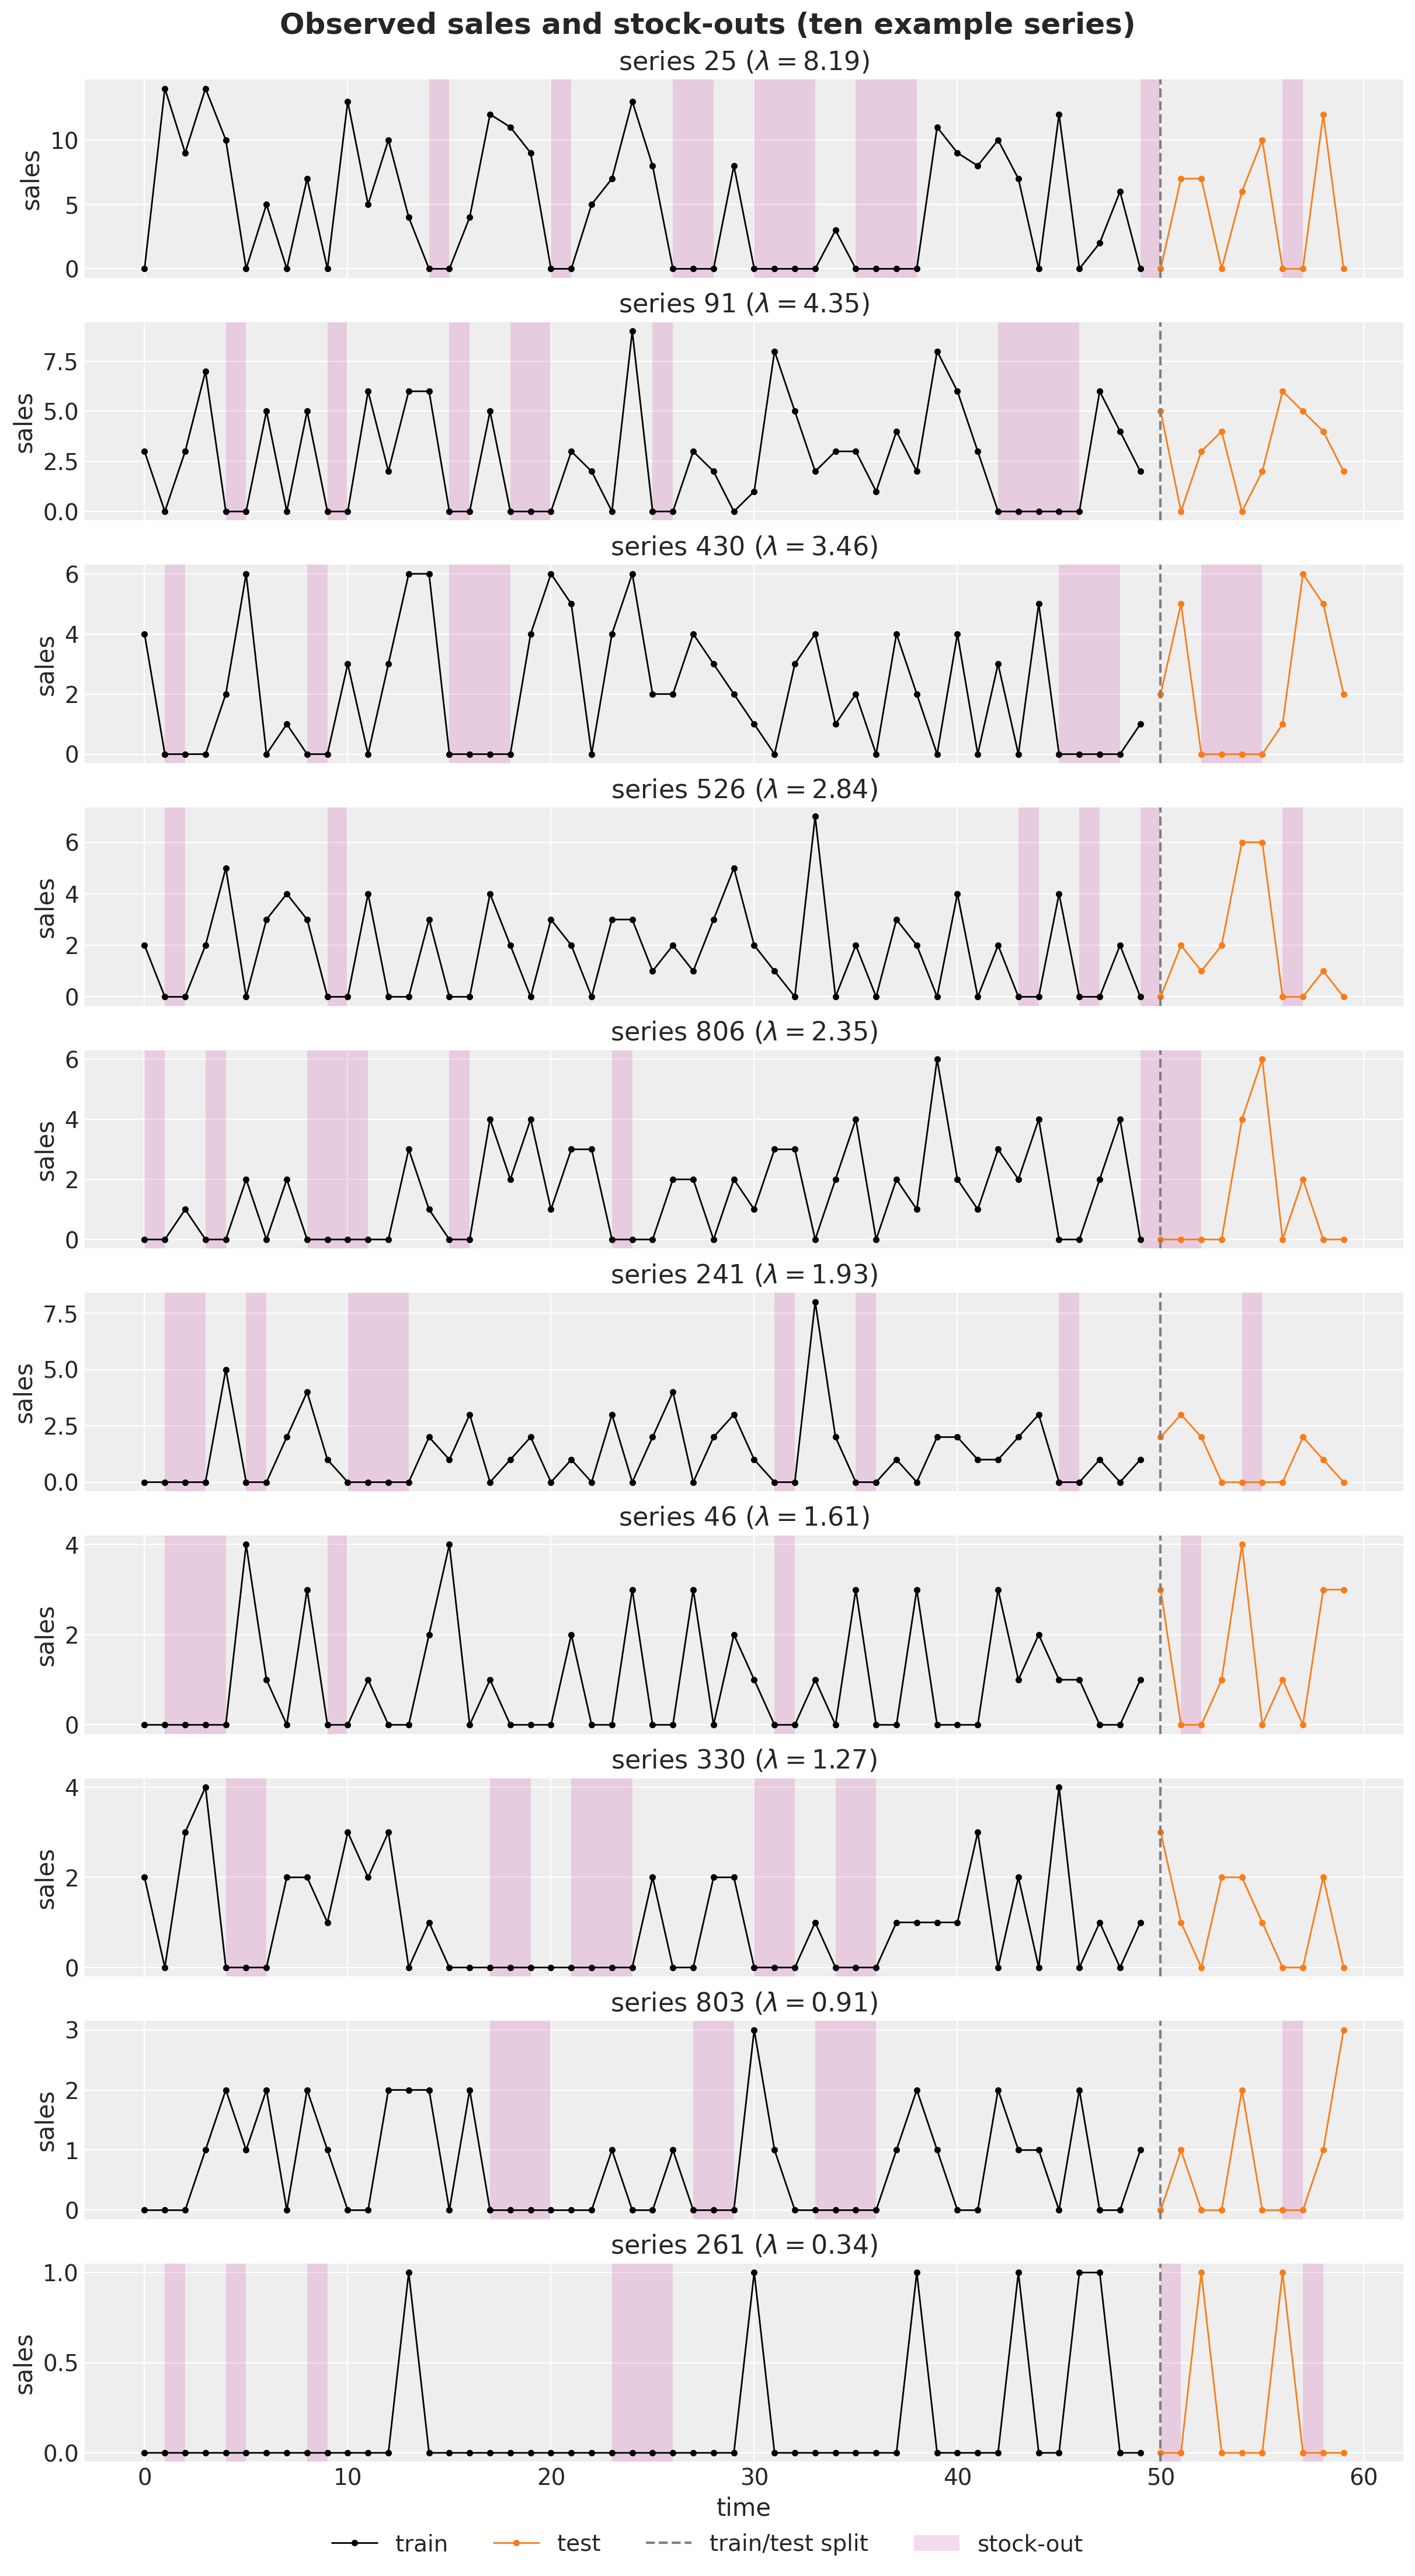

In [5]:
def shade_stockouts(ax: Axes, t_axis: np.ndarray, available: np.ndarray) -> Artist:
    """Shade the periods where the product is off the shelf.

    Parameters
    ----------
    ax
        The axes to draw on.
    t_axis
        Time values of length ``time``.
    available
        The 0/1 availability values along ``t_axis``.

    Returns
    -------
    Artist
        The shading artist, labeled ``"stock-out"`` for legends.
    """
    return ax.fill_between(
        t_axis,
        0,
        1,
        where=np.asarray(available) == 0,
        step="mid",
        transform=ax.get_xaxis_transform(),
        color="C3",
        alpha=0.15,
        lw=0,
        label="stock-out",
    )


order = np.argsort(lam)[::-1]
example_series = int(order[10])
display_series = [int(order[rank]) for rank in np.linspace(5, n_series - 10, 10, dtype=int)]
print(
    f"display series {display_series} with rates "
    f"{[round(float(lam[i]), 2) for i in display_series]}"
)

fig, axes = plt.subplots(
    nrows=10, ncols=1, figsize=(12, 22), sharex=True, sharey=False, layout="constrained"
)
for ax, i in zip(axes, display_series, strict=True):
    ax.plot(t_train, train_data[:, i], "o-", color="black", lw=1, ms=3, label="train")
    ax.plot(t_test, test_data[:, i], "o-", color="C1", lw=1, ms=3, label="test")
    shade = shade_stockouts(ax, t, np.asarray(panel.available[:, i]))
    split_line = ax.axvline(t_max_train, color="gray", ls="--", label="train/test split")
    ax.set(title=rf"series {i} ($\lambda = {lam[i]:.2f}$)", ylabel="sales")
axes[-1].set(xlabel="time")
train_line, test_line = axes[-1].get_lines()[:2]
fig.legend(
    handles=[train_line, test_line, split_line, shade],
    loc="outside lower center",
    ncol=4,
)
fig.suptitle("Observed sales and stock-outs (ten example series)", fontsize=18, fontweight="bold");

## From Croston to TSB to availability constraints

All three methods in this trilogy decompose the sparse series into a **demand size** and an **occurrence** component and run simple exponential smoothing on each; they differ only in what the occurrence component is and *when* it updates. Writing $\ell_t$ for a component level, every recursion below is the same masked update $\ell_t = \ell_{t-1} + g_t \, \alpha \, (x_t - \ell_{t-1})$ with a different gate $g_t$:

| method | occurrence component | update gate $g_t$ | what $\hat{p}$ estimates under stock-outs |
|---|---|---|---|
| Croston | inverse inter-demand interval | demand events only | interval-based, availability inflates intervals |
| TSB | demand indicator $d_t$ | every period | $P(\text{available}) \cdot P(\text{demand} \mid \text{available})$ |
| availability TSB | demand indicator $d_t$ | available periods $a_t = 1$ | $P(\text{demand} \mid \text{available})$ |

[Croston's method](https://juanitorduz.github.io/numpyro_forecast/examples/croston.html) updates both components only at demand events, so a stock-out run simply freezes it, but it also *stretches the measured inter-demand intervals*: the drought caused by the stock-out is booked as demand slowing down, and there is no natural place in the interval bookkeeping to discount it. [TSB](https://juanitorduz.github.io/numpyro_forecast/examples/tsb.html) replaces the intervals with the demand indicator $d_t = \mathbf{1}[y_t > 0]$ smoothed at every period:

$$
\hat{p}_t =
\begin{cases}
\beta + (1 - \beta) \, \hat{p}_{t-1} & \text{if } y_t > 0, \\
(1 - \beta) \, \hat{p}_{t-1} & \text{if } y_t = 0.
\end{cases}
$$

This is the method's strength on genuinely fading demand and its weakness under censoring: the second branch fires on stock-out zeros too. The blog post's hack rewrites the zero branch as

$$
\hat{p}_t = (1 - a_t \, \beta) \, \hat{p}_{t-1},
$$

so an on-shelf zero ($a_t = 1$) decays the probability exactly as in TSB, while an off-shelf period ($a_t = 0$) leaves it untouched. Since a sale requires the product on the shelf ($y_t > 0 \Rightarrow a_t = 1$), all branches collapse into the single gated recursion

$$
\hat{p}_t = \hat{p}_{t-1} + a_t \, \beta \, (d_t - \hat{p}_{t-1}):
$$

simple exponential smoothing of the demand indicator, updated **only when the product is available**. The point forecast becomes $\hat{y}_{t+h} = a_{t+h} \, \hat{z}_t \, \hat{p}_t$ with the *future* availability $a_{t+h}$ chosen by the forecaster, which is what turns the model into a scenario tool. And because plain TSB is recovered exactly by setting $a_t \equiv 1$, the comparison at the end of this notebook needs no second model: it just feeds the same model an all-ones availability input.

## Prior for the smoothing parameters

Both smoothing parameters get a $\text{Beta}(1.5, 3)$ prior. This is a genuinely weakly informative choice: most of its mass still sits at the small values classical practice expects for smoothing parameters (roughly $[0.1, 0.3]$), but the density stays meaningfully positive across the whole unit interval, so a series whose data call for a very stiff level (near $0$) or a very reactive one (near $1$) can reach it without fighting the prior. Contrast this with the blog post's $\text{Beta}(10, 40)$, which pins the parameter to a narrow band around $0.2$; with $1{,}000$ series each contributing its own posterior, there is no reason to constrain them that tightly a priori, and we let the data decide instead.

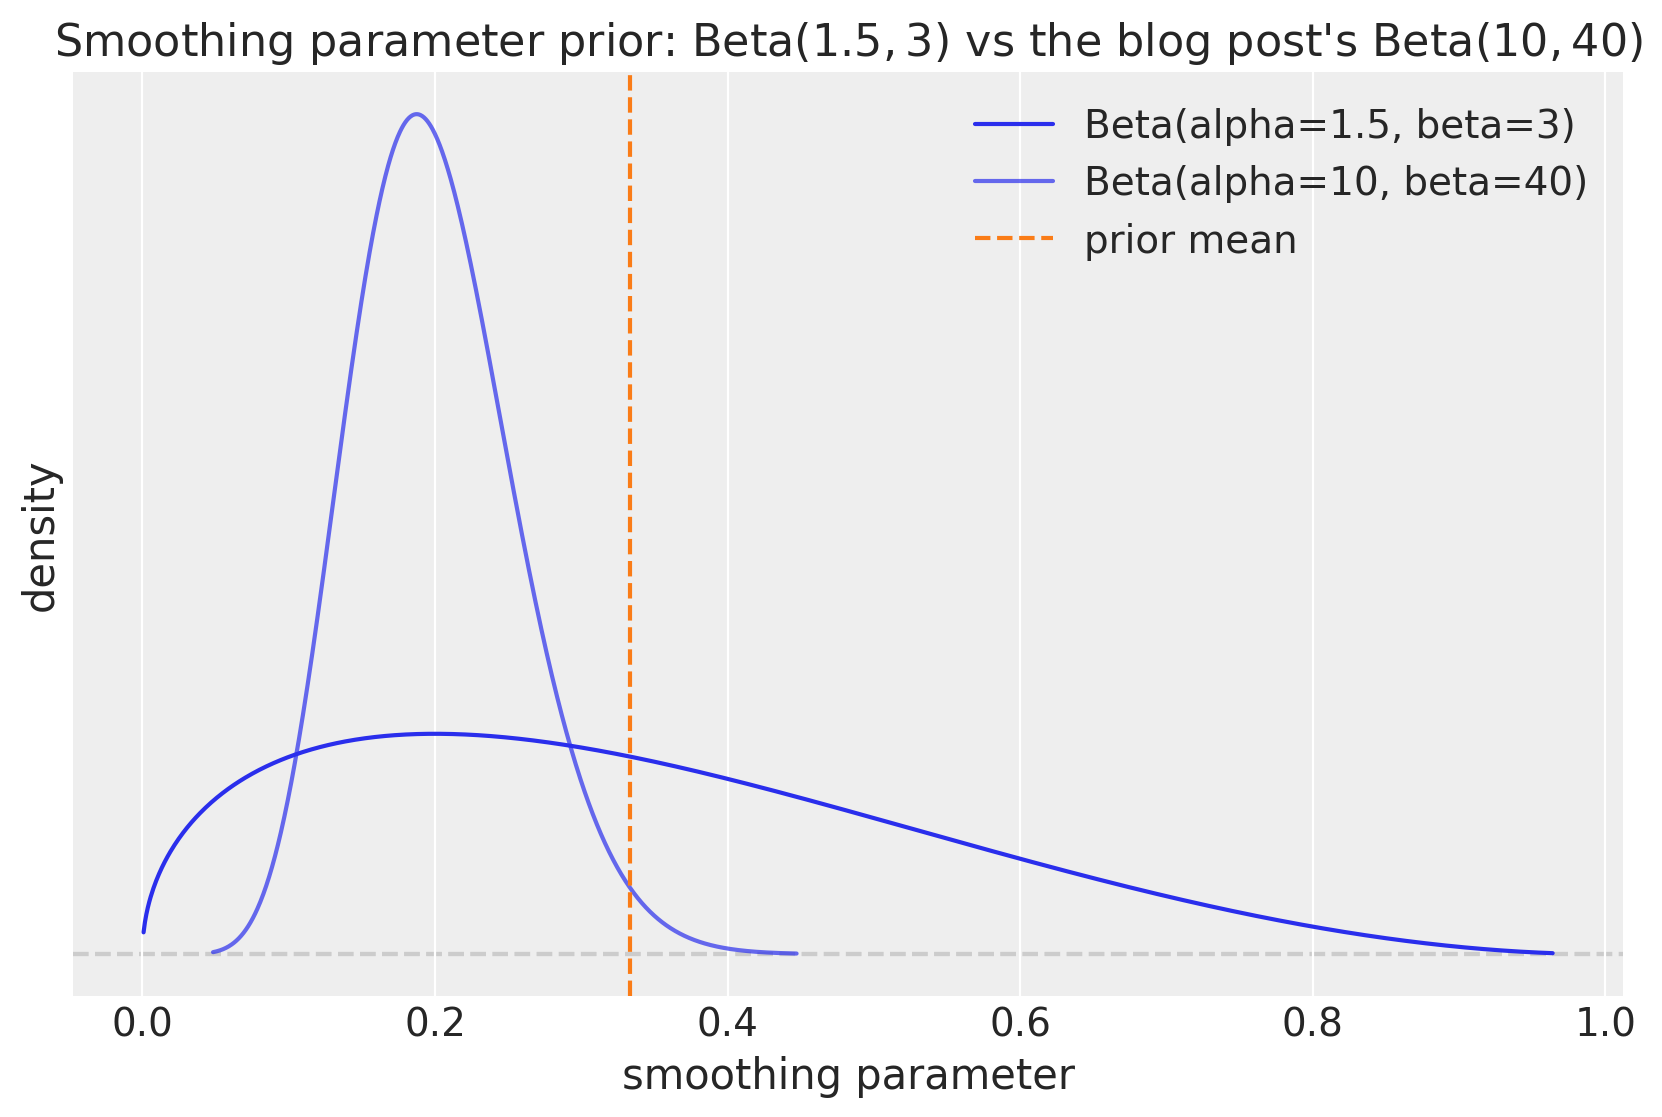

In [6]:
prior_mean = 1.5 / 4.5

fig, ax = plt.subplots(figsize=(10, 6))
pz.Beta(1.5, 3).plot_pdf(ax=ax, color="C0")
pz.Beta(10, 40).plot_pdf(ax=ax, alpha=0.7)
ax.axvline(prior_mean, color="C1", ls="--", label="prior mean")
ax.legend()
ax.set(
    title=r"Smoothing parameter prior: $\text{Beta}(1.5, 3)$ vs the blog post's $\text{Beta}(10, 40)$",
    xlabel="smoothing parameter",
    ylabel="density",
);

## Model specification

The model is the TSB notebook's two-component construction promoted to a panel, with one structural change. The reusable `panel_level_model` runs the gated level recursion for all series at once: the per-series parameters (sites `smoothing` and `noise`) are sampled inside a `numpyro.plate` over series, one `jax.lax.scan` over the calendar axis carries the whole `(series,)` level vector, and, when forecasting, the component draws its flat predictive at a site named `future`. Composing with NumPyro's [`scope`](https://num.pyro.ai/en/stable/handlers.html#scope) handler under the prefixes `z` and `p` yields the parameter names `z_smoothing`, ..., `p_future`, just like the siblings.

The remaining choices, and where their numbers come from:

- **Level inits.** Following the blog post, the levels start deterministically rather than sampled as in the sibling notebooks: the demand-size level starts at the first observation, $\ell^z_0 = y_0$, and the demand probability starts at $\hat{p}_0 = 0.5$, the agnostic "no idea whether this period sees demand" value that the data then pull toward each series' true probability.
- **Noise priors.** The demand-size noise is hierarchical: a global scale $\sigma_{\text{scale}} \sim \text{LogNormal}(\log 5, 1)$ (centered on the blog post's value of $5$ but with a log-scale of $1$ instead of its $0.3$, spanning an order of magnitude in either direction) with per-series $\sigma_i \sim \text{HalfNormal}(\sigma_{\text{scale}})$, which shares strength across $1{,}000$ series that individually see only a handful of demand events. The probability component instead gets a fixed weakly informative $\sigma_i \sim \text{HalfNormal}(1)$: its observations live in $[0, 1]$, so a scale of order one is already essentially flat and there is nothing for a hierarchy to learn.
- **Noise floors.** One pragmatic addition over the blog post: each component's observation scale gets a small constant floor ($0.1$ on the sizes, $0.05$ on the indicator, well below any scale the data support). With this many series, some have every training demand equal (all $1$s is common for slow movers) or no on-shelf demand at all, and without the floor SVI drives those series' scales toward zero until the ELBO turns NaN late in the optimization.

The `availability_tsb` body then does what is specific to this method:

1. **Bookkeeping.** From the covariates it reads the observed sales prefix (input `0`), the availability mask (input `1`), and the *future* availability rows, and builds the demand indicator.
2. **The one-line innovation.** The demand-size component is gated by `is_demand`, exactly as in Croston and TSB. The demand-probability component smooths the indicator gated by `available`: where the TSB notebook passes an all-true `every_period` gate, this model passes the availability mask. That single argument is the whole method.
3. **In sample.** The size likelihood `"obs"` is masked to demand events, as in the siblings. The probability likelihood `"obs_prob"` is masked to *available* periods: an off-shelf indicator observation carries no demand information, so it contributes no likelihood either. The deterministic sites expose the uncensored `"demand_rate"` ($\hat{z}_{t-1} \hat{p}_{t-1}$), the censored `"rate"` ($a_t \hat{z}_{t-1} \hat{p}_{t-1}$, the expected *sales*), and the probability path `"prob"`.
4. **Out of sample.** The `"forecast"` site is the component predictives' product times the future availability read from the covariates, $a \cdot \hat{z} \cdot \hat{p}$, so the same fitted model forecasts any availability scenario.

In [7]:
def panel_level_model(
    values: Array,
    is_event: Array,
    future: int,
    init: Array,
    noise_scale: Array | float,
    noise_floor: float,
) -> tuple[Array, Array, Array | None]:
    """Gated simple exponential smoothing level model on a ``(time, series)`` panel.

    Samples the per-series component priors (sites ``smoothing``, ``noise``)
    inside a plate over series, runs the where-gated level recursion along the
    calendar axis, and, when ``future > 0``, draws the flat forecast predictive
    at the site ``future``. Meant to be called under
    :func:`numpyro.handlers.scope`, which prefixes the site names per component.
    This is the sibling notebooks' ``level_model`` promoted to a panel, with
    deterministic inits and a hierarchical noise scale following the blog post.

    Parameters
    ----------
    values
        Observed component values, shape ``(time, series)``; read only where
        ``is_event`` is true.
    is_event
        Boolean update gate, shape ``(time, series)``; the level only updates
        where it is true (the availability mask for the demand-probability
        component).
    future
        Number of forecast steps (``0`` while training).
    init
        Initial level per series, shape ``(series,)``.
    noise_scale
        Scale of the ``HalfNormal`` prior on the per-series observation noise.
    noise_floor
        Constant added to the sampled noise, keeping the observation scale
        away from zero for series whose component values are constant.

    Returns
    -------
    tuple[Array, Array, Array | None]
        The one-step-ahead means (the pre-update levels), the observation noise
        scale, and the forecast predictive draws (``None`` when ``future == 0``).
    """
    n_series = values.shape[-1]

    with numpyro.plate("series", n_series):
        # cast() only narrows numpyro's union return type for the type checker.
        smoothing = cast(
            Array, numpyro.sample("smoothing", dist.Beta(concentration1=1.5, concentration0=3))
        )
        noise = noise_floor + cast(
            Array, numpyro.sample("noise", dist.HalfNormal(scale=noise_scale))
        )

    def transition_fn(carry, inputs):
        x_t, event_t = inputs
        level = jnp.where(event_t, smoothing * x_t + (1 - smoothing) * carry, carry)
        # Emit the pre-update level: the one-step-ahead mean.
        return level, carry

    last_level, mu = jax.lax.scan(transition_fn, init, (values, is_event))

    future_draws = None
    if future > 0:
        future_draws = cast(
            Array,
            numpyro.sample(
                "future",
                dist.Normal(loc=last_level, scale=noise).expand([future, n_series]).to_event(2),
            ),
        )
    return mu, noise, future_draws


def availability_tsb(h: Horizon, covariates: Array) -> None:
    """TSB with an availability-gated demand-probability component, on a series panel.

    Identical to the TSB body except for the demand-probability component's
    update gate: the availability mask (input ``1`` of the covariates) instead
    of an all-true every-period gate. Plain TSB is recovered exactly by
    feeding an all-ones availability input.

    Parameters
    ----------
    h
        The train/forecast horizon for the current model call.
    covariates
        Two-input tensor ``(covariate, time, series)`` spanning the full
        horizon: input ``0`` is the observed sales history (only the first
        ``h.t_obs`` rows are read), input ``1`` the availability mask (its
        trailing rows define the forecast's availability scenario).
    """
    y = covariates[0, : h.t_obs, :]
    available = covariates[1, : h.t_obs, :] > 0
    available_future = covariates[1, h.t_obs :, :]
    is_demand = y > 0
    demand_indicator = is_demand.astype(y.dtype)

    # cast() only narrows numpyro's union return type for the type checker.
    noise_scale = cast(
        Array, numpyro.sample("noise_scale", dist.LogNormal(loc=jnp.log(5), scale=1))
    )

    # Demand-size component: identical to Croston/TSB (updates only at demand events).
    z_mu, z_noise, z_future = scope(panel_level_model, "z", divider="_")(
        y, is_demand, h.future, init=y[0], noise_scale=noise_scale, noise_floor=0.1
    )
    # Demand-probability component: THE one-line innovation. TSB passes an
    # all-true gate here; the availability mask freezes the update off the shelf.
    p_mu, p_noise, p_future = scope(panel_level_model, "p", divider="_")(
        demand_indicator,
        available,
        h.future,
        init=0.5 * jnp.ones_like(y[0]),
        noise_scale=1.0,
        noise_floor=0.05,
    )

    numpyro.deterministic("demand_rate", z_mu * p_mu)
    numpyro.deterministic("rate", available * z_mu * p_mu)
    numpyro.deterministic("prob", p_mu)
    numpyro.sample("obs", dist.Normal(loc=z_mu, scale=z_noise).mask(is_demand), obs=h.data)
    numpyro.sample(
        "obs_prob",
        dist.Normal(loc=p_mu, scale=p_noise).mask(available),  # off-shelf: no likelihood
        obs=demand_indicator,
    )

    if z_future is not None and p_future is not None:  # exactly when h.future > 0
        numpyro.deterministic("z_forecast", z_future)
        numpyro.deterministic("p_forecast", p_future)
        numpyro.deterministic("forecast", available_future * z_future * p_future)


model = forecasting_model(availability_tsb)

### Prior predictive check

Before fitting we draw from the prior predictive with NumPyro's `Predictive` and look at the implied `"rate"` paths for one example series. The recursions are driven by the observed history through the covariates, so even under the prior the rate follows the data's rough shape; what the prior controls is how strongly each observation moves the levels and hence how wide the band of plausible paths is. Under the wide $\text{Beta}(1.5, 3)$ prior that band is genuinely broad: it spans everything from a stiff level that barely reacts to a reactive one that chases the observations up to their spikes, which is exactly the agnosticism we want before seeing the likelihood. This cell also defines the small band-plot helpers (`hdi_label`, `stacked_draws`, and `plot_band_forecast`, shared with the sibling notebooks) used by every band plot below.

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(


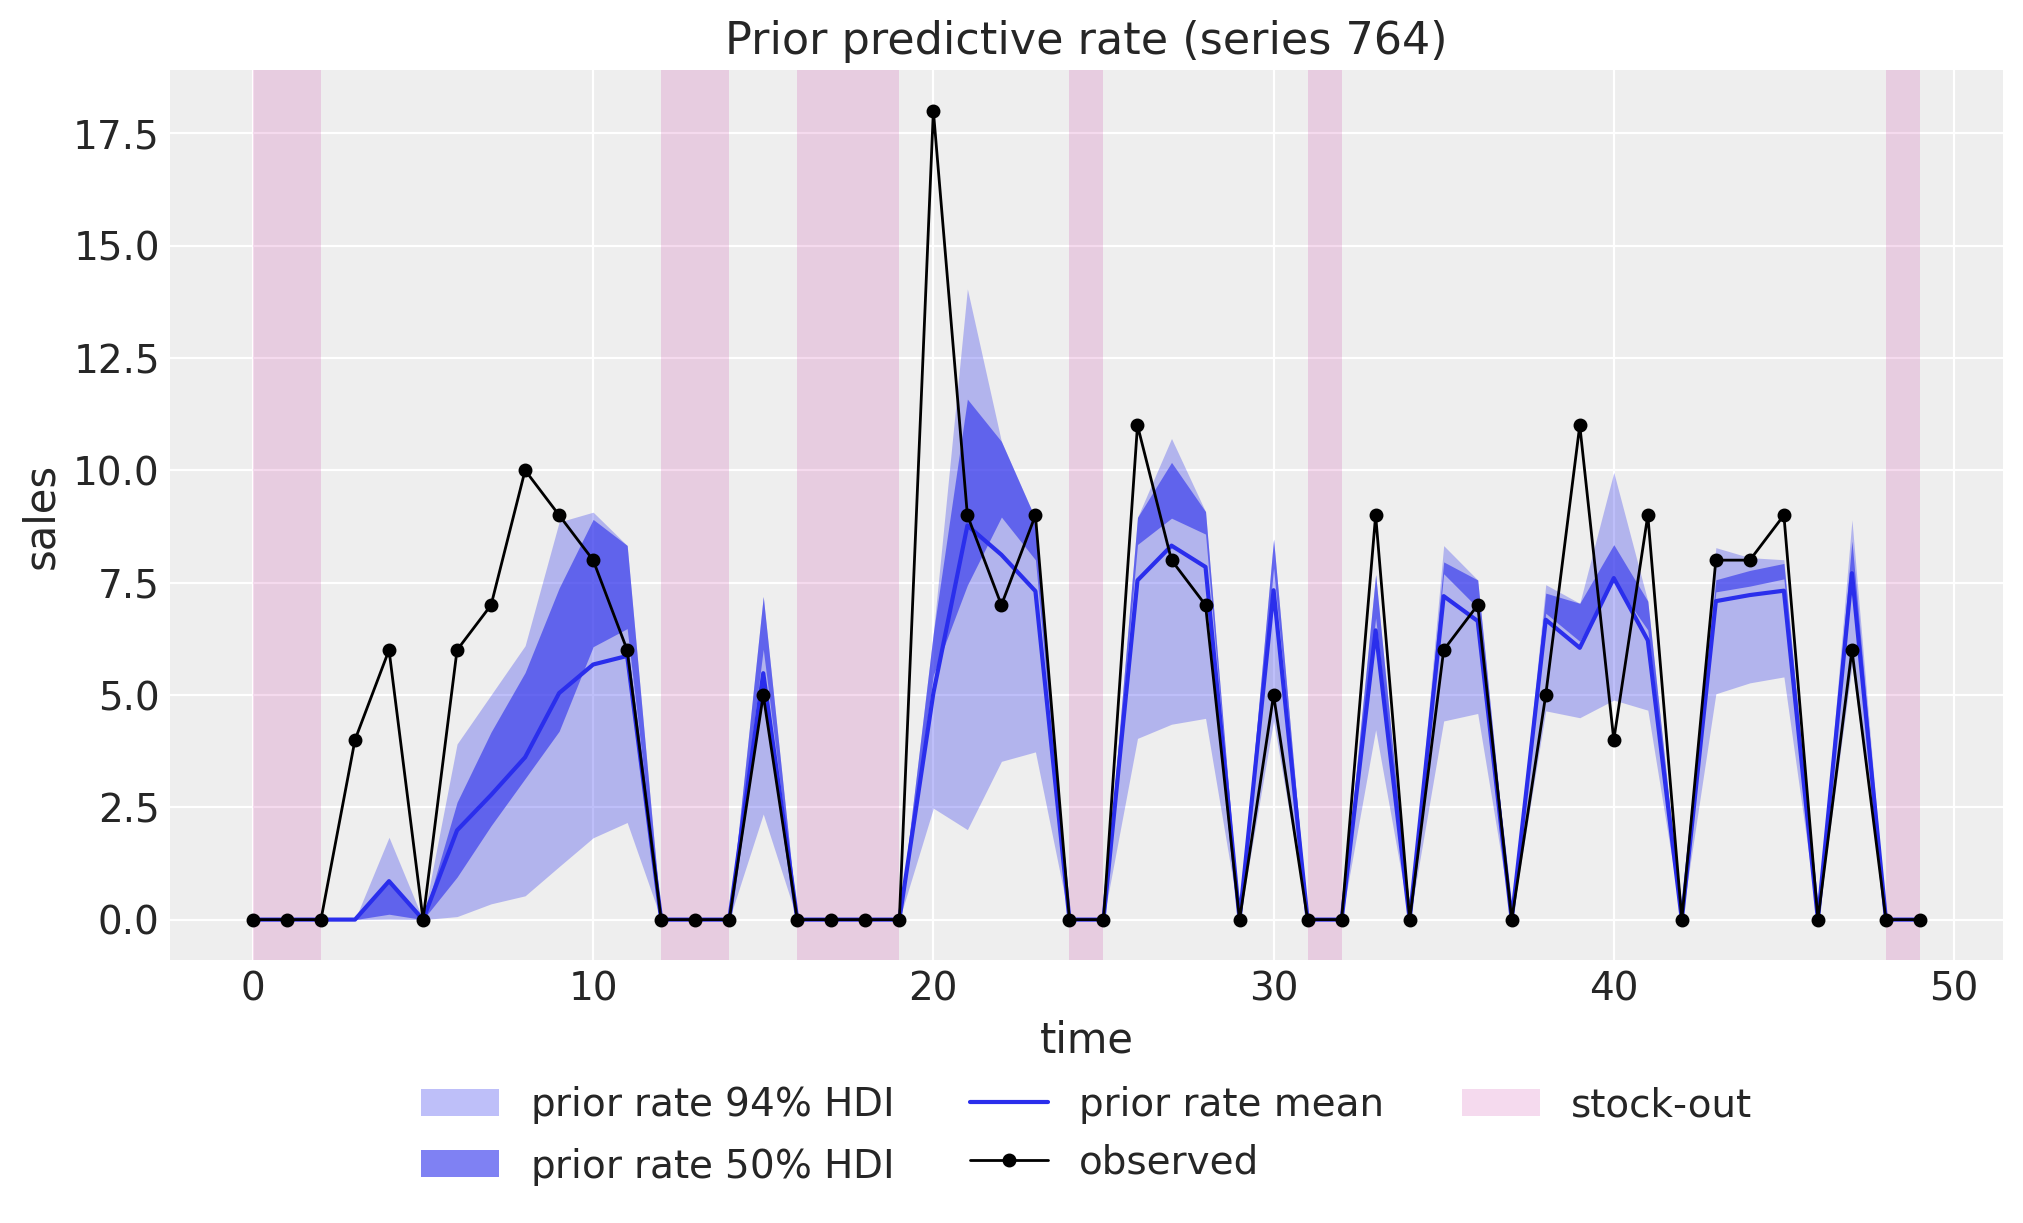

In [8]:
def hdi_label(prob: float, prefix: str = "") -> str:
    r"""Legend label for an HDI band, e.g. ``$94\%$ HDI``."""
    percent = f"{prob:.0%}".replace("%", r"\%")
    return f"{prefix}${percent}$ HDI"


hdi_probs = (0.5, 0.94)
hdi_alphas = [0.6, 0.3]  # 50% band darker, 94% band lighter


def stacked_draws(group: xr.DataTree | xr.DataArray, var: str) -> np.ndarray:
    """Stack a tree variable's ``(chain, draw)`` dims into a leading sample axis.

    Parameters
    ----------
    group
        A tree group holding ``var`` with dims ``(chain, draw, time, obs_dim)``
        (typed as the union ``tree[...]`` returns; a group always arrives here).
    var
        Name of the variable to extract.

    Returns
    -------
    np.ndarray
        The draws with shape ``(sample, time, obs_dim)``.
    """
    return (
        group.dataset[var]
        .stack(sample=("chain", "draw"))
        .transpose("sample", "time", "obs_dim")
        .to_numpy()
    )


def plot_band_forecast(
    draws: np.ndarray,
    x: np.ndarray,
    color: str,
    label_prefix: str = "",
    observed: Array | np.ndarray | None = None,
    figsize: tuple[float, float] = (12.0, 6.0),
) -> tuple[Axes, list[Artist]]:
    r"""Plot the posterior mean line and the $50\%$/$94\%$ HDI bands of ``draws``.

    Wraps ``predictions_to_datatree`` and ``az.plot_lm`` with the notebook-wide
    band styling (inner band darker via ``hdi_alphas``) and labels the artists.
    Overlays (observed series, split lines, stock-out shading) and the legend
    are the caller's responsibility.

    Parameters
    ----------
    draws
        Predictive draws with shape ``(sample, time, 1)``.
    x
        Numeric x values of length ``time``.
    color
        Matplotlib color for the bands and the mean line.
    label_prefix
        Prefix for the legend labels, e.g. ``"forecast "``.
    observed
        Optional observed data stored alongside the draws.
    figsize
        Figure size passed to ``plot_lm``.

    Returns
    -------
    tuple[Axes, list[Artist]]
        The axes and the labeled band and mean-line handles for the legend.
    """
    idata = predictions_to_datatree(draws, x, ["y"], observed=observed)
    pc = az.plot_lm(
        idata,
        y="obs",
        x="t",
        plot_dim="time",
        ci_kind="hdi",
        ci_prob=hdi_probs,
        smooth=False,
        point_estimate="mean",
        visuals={
            "ci_band": {"color": color},
            "observed_scatter": False,
            "pe_line": {"color": color, "alpha": 1.0, "width": 1.5},
        },
        aes={"alpha": ["prob"]},
        alpha=hdi_alphas,
        figure_kwargs={"figsize": figsize},
    )
    bands = pc.viz["ci_band"]["t"]
    band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
    band_94.set_label(hdi_label(0.94, prefix=label_prefix))
    band_50.set_label(hdi_label(0.5, prefix=label_prefix))
    pe_line = pc.viz["pe_line"]["t"].item()
    pe_line.set_label(f"{label_prefix}posterior mean")
    ax = pc.viz["figure"].item().axes[0]
    return ax, [band_94, band_50, pe_line]


rng_key, rng_subkey = random.split(rng_key)
prior_predictive = Predictive(model, num_samples=500)
prior_samples = prior_predictive(rng_subkey, covariates_train)
prior_rate = np.asarray(prior_samples["rate"])

i = example_series
ax, handles = plot_band_forecast(
    prior_rate[:, :, [i]],
    t_train.astype(float),
    "C0",
    label_prefix="prior rate ",
    figsize=(10.0, 6.0),
)
(obs_line,) = ax.plot(
    t_train, np.asarray(train_data[:, i]), "o-", color="black", lw=1, ms=4, label="observed"
)
shade = shade_stockouts(ax, t_train, np.asarray(available_train[:, i]))
handles[2].set_label("prior rate mean")
ax.legend(
    handles=[*handles, obs_line, shade],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
ax.set(title=f"Prior predictive rate (series {i})", xlabel="time", ylabel="sales");

## Inference with SVI

With $1{,}000$ series the posterior has about $4{,}000$ latent dimensions (four per-series parameters, the two components' smoothing and noise, plus the global noise scale), which is exactly the regime where the sibling notebooks' NUTS setup stops being the right tool and stochastic variational inference shines. We fit with the functional [`fit_svi`](https://juanitorduz.github.io/numpyro_forecast/reference/functional.svi.fit_svi.html), following the blog post's configuration: an `AutoNormal` guide (the default) and `Adam` with learning rate $0.001$ for $10{,}000$ steps. The ELBO loss settles well before the end of the run.

mean ELBO loss over the last 100 steps: 56,657
CPU times: user 10.4 s, sys: 3.23 s, total: 13.6 s
Wall time: 6.02 s


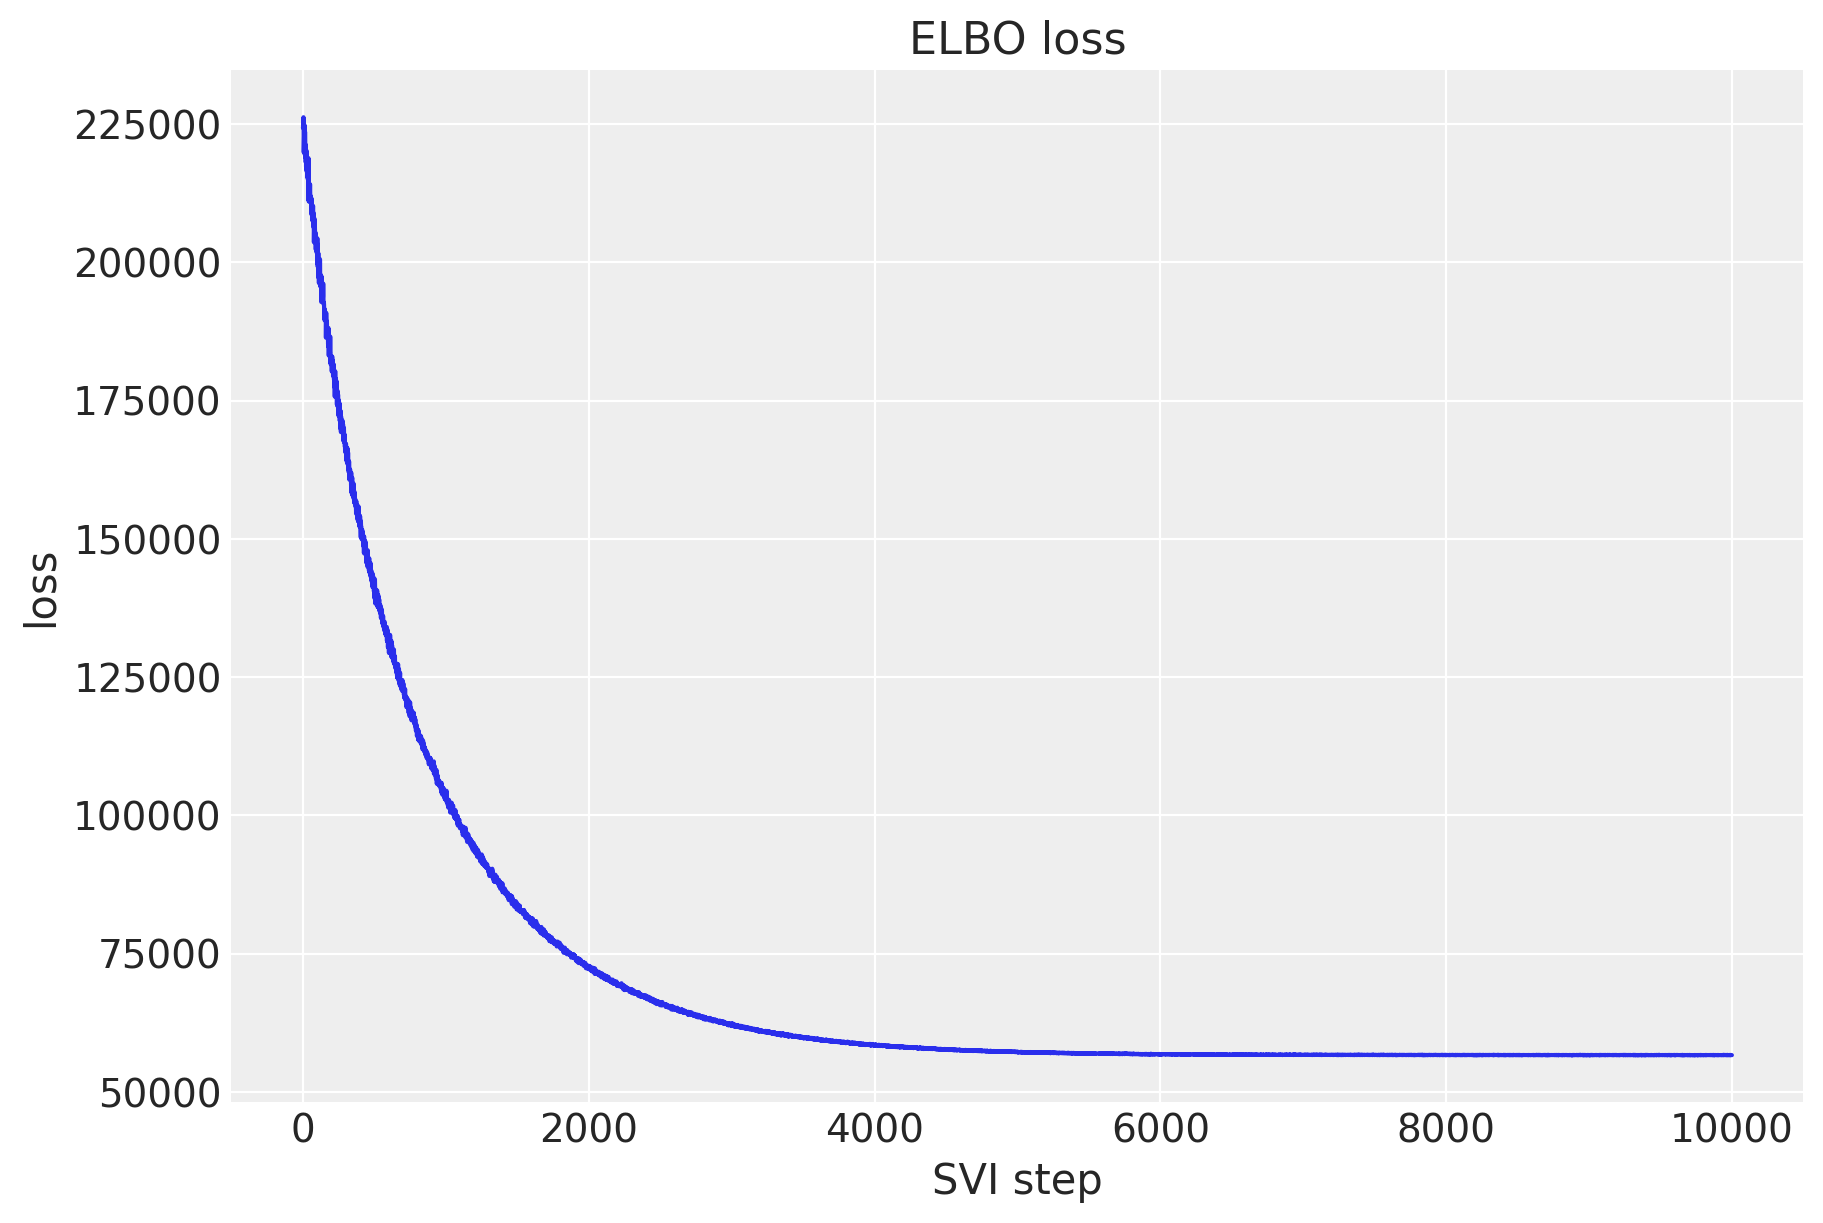

In [9]:
%%time

num_steps = 10_000

rng_key, rng_subkey = random.split(rng_key)
fit = fit_svi(
    rng_subkey,
    model,
    train_data,
    covariates_train,
    optim=0.001,
    num_steps=num_steps,
)
print(f"mean ELBO loss over the last 100 steps: {float(jnp.mean(fit.losses[-100:])):,.0f}")

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(np.asarray(fit.losses))
ax.set(title="ELBO loss", xlabel="SVI step", ylabel="loss");

## Diagnostics

We export the fit into an ArviZ-schema `xarray.DataTree` with [`to_datatree`](https://juanitorduz.github.io/numpyro_forecast/reference/convert.to_datatree.html). Because we pass the *extended* covariates (whose availability input carries the realized test availability), the tree automatically gains `predictions` groups holding the out-of-sample forecast draws for that scenario. We register the three per-timestep deterministics so they share the tree-wide `time` coordinate, name the covariate axes explicitly (the covariates are `3`-D here, so the default two-name layout does not apply), and bound the accelerator memory of the predictive pass with `predictive_batch_size`, since every stored site on this panel is a `(draws, time, series)` block.

In [10]:
rng_key, rng_subkey = random.split(rng_key)
tree = to_datatree(
    rng_subkey,
    fit,
    model,
    train_data,
    covariates_full,
    num_predictive_samples=1_000,
    predictive_batch_size=250,
    posterior_dims={
        "rate": ["time", "obs_dim"],
        "demand_rate": ["time", "obs_dim"],
        "prob": ["time", "obs_dim"],
    },
    covariate_dims=["covariate", "time", "obs_dim"],
    coords={"covariate": ["sales", "availability"]},
)
tree

<xarray.DataTree>
Group: /
│   Attributes:
│       inference_library:  numpyro
│       creation_library:   numpyro_forecast
│       sample_dims:        ['chain', 'draw']
├── Group: /posterior
│       Dimensions:            (chain: 1, draw: 1000, time: 50, obs_dim: 1000,
│                               p_noise_dim_0: 1000, p_smoothing_dim_0: 1000,
│                               z_noise_dim_0: 1000, z_smoothing_dim_0: 1000)
│       Coordinates:
│         * chain              (chain) int64 8B 0
│         * draw               (draw) int64 8kB 0 1 2 3 4 5 ... 994 995 996 997 998 999
│         * time               (time) int64 400B 0 1 2 3 4 5 6 ... 43 44 45 46 47 48 49
│         * obs_dim            (obs_dim) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
│         * p_noise_dim_0      (p_noise_dim_0) int64 8kB 0 1 2 3 4 ... 996 997 998 999
│         * p_smoothing_dim_0  (p_smoothing_dim_0) int64 8kB 0 1 2 3 ... 996 997 998 999
│         * z_noise_dim_0      (z_noise_dim_0) int64 8kB 0 1 2 3 4 ... 996 997 998 999
│         * z_smoothing_dim_0  (z_smoothing_dim_0) int64 8kB 0 1 2 3 ... 996 997 998 999
│       Data variables:
│           demand_rate        (chain, draw, time, obs_dim) float32 200MB 0.5 ... 3.074
│           noise_scale        (chain, draw) float32 4kB 1.615 1.647 1.64 ... 1.65 1.6
│           p_noise            (chain, draw, p_noise_dim_0) float32 4MB 0.2493 ... 0....
│           p_smoothing        (chain, draw, p_smoothing_dim_0) float32 4MB 0.4641 .....
│           prob               (chain, draw, time, obs_dim) float32 200MB 0.5 ... 0.9885
│           rate               (chain, draw, time, obs_dim) float32 200MB 0.5 ... 0.0
│           z_noise            (chain, draw, z_noise_dim_0) float32 4MB 2.553 ... 1.536
│           z_smoothing        (chain, draw, z_smoothing_dim_0) float32 4MB 0.1851 .....
│       Attributes:
│           created_at:                 2026-07-21T20:42:03.486023+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           variational:                True
├── Group: /posterior_predictive
│       Dimensions:  (chain: 1, draw: 1000, time: 50, obs_dim: 1000)
│       Coordinates:
│         * chain    (chain) int64 8B 0
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│         * time     (time) int64 400B 0 1 2 3 4 5 6 7 8 ... 41 42 43 44 45 46 47 48 49
│         * obs_dim  (obs_dim) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│       Data variables:
│           obs      (chain, draw, time, obs_dim) float32 200MB 4.629 0.009904 ... 5.943
│       Attributes:
│           created_at:                 2026-07-21T20:42:03.842623+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:  (time: 50, obs_dim: 1000)
│       Coordinates:
│         * time     (time) int64 400B 0 1 2 3 4 5 6 7 8 ... 41 42 43 44 45 46 47 48 49
│         * obs_dim  (obs_dim) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│       Data variables:
│           obs      (time, obs_dim) float32 200kB 1.0 1.0 2.0 3.0 ... 2.0 0.0 0.0 0.0
│       Attributes:
│           created_at:                 2026-07-21T20:42:03.842856+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                []
├── Group: /constant_data
│       Dimensions:     (covariate: 2, time: 50, obs_dim: 1000)
│       Coordinates:
│         * covariate   (covariate) <U12 96B 'sales' 'availability'
│         * time        (time) int64 400B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
│         * obs_dim     (obs_dim) int64 8kB 0 1 2 3 4 5 6 ... 994 995 

A variational fit has no chains to converge, so the MCMC diagnostics of the sibling notebooks ($\hat{R}$, effective sample sizes) do not apply; the ELBO curve above plays their role. What we can inspect is the fitted posterior itself. `az.summary` on the global noise scale checks the one shared parameter, and for the $1{,}000$-dimensional per-series sites we look at the *distribution* of posterior-mean smoothing parameters across series against the prior mean.

In [11]:
az.summary(tree, var_names=["noise_scale"], ci_kind="hdi", ci_prob=0.94, kind="stats")

,mean,sd,hdi94_lb,hdi94_ub
noise_scale,1.6,0.038,1.6,1.7


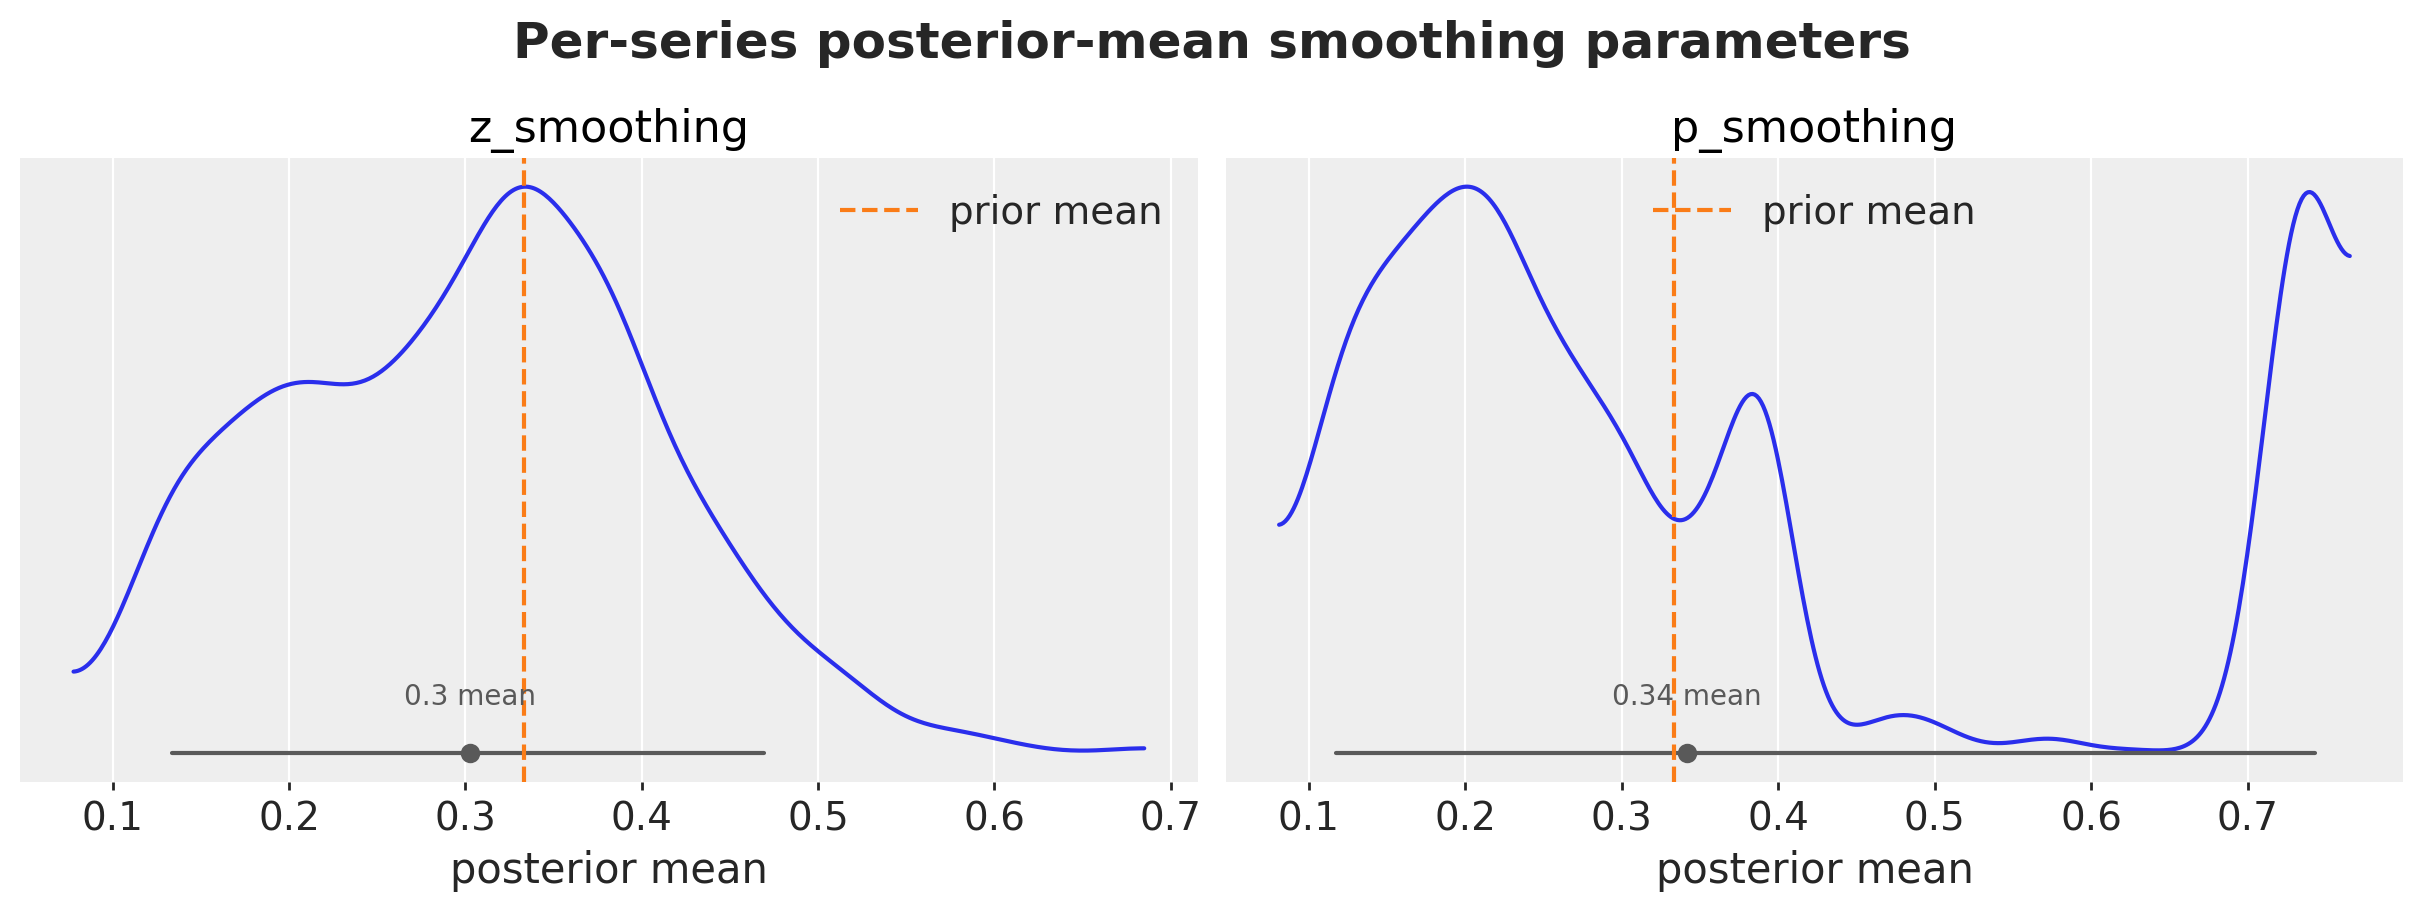

In [12]:
posterior = tree["posterior"].dataset
z_sm = posterior["z_smoothing"].mean(dim=("chain", "draw")).to_numpy()
p_sm = posterior["p_smoothing"].mean(dim=("chain", "draw")).to_numpy()

smoothing_means = xr.DataTree.from_dict(
    {"posterior": xr.Dataset({"z_smoothing": ("series", z_sm), "p_smoothing": ("series", p_sm)})}
)
pc = az.plot_dist(
    smoothing_means, sample_dims=["series"], kind="kde", figure_kwargs={"figsize": (12, 4)}
)
for name in ["z_smoothing", "p_smoothing"]:
    ax = pc.viz["plot"][name].item()
    ax.axvline(prior_mean, color="C1", ls="--", label="prior mean")
    ax.legend()
    ax.set(xlabel="posterior mean")
fig = pc.viz["plot"]["z_smoothing"].item().figure
fig.suptitle(
    "Per-series posterior-mean smoothing parameters", fontsize=18, fontweight="bold", y=1.1
);

How to read these two shapes. A small smoothing parameter means a *stiff* level (each new observation nudges the estimate only slightly), a large one a *reactive* level that chases the latest observations. The size component (`z_smoothing`) comes out unimodal, concentrated around its annotated mean of $0.3$: demand sizes are i.i.d. within each series, so there is no genuine trend to chase, and the likelihood settles on moderate values that average over the Poisson noise rather than track it. The probability component (`p_smoothing`) is the interesting one: its distribution is *multimodal*, with a distinct cluster of series at clearly larger values. That upper cluster is not noise; it is the fastest movers. Their true demand probability sits near $1$, so their demand indicator is an almost constant string of ones, and the quickest way for the recursion to explain it is to escape the agnostic $\hat{p}_0 = 0.5$ initialization in a few steps, which requires a large smoothing parameter. The scatter below makes the link explicit, and the printed split quantifies it.

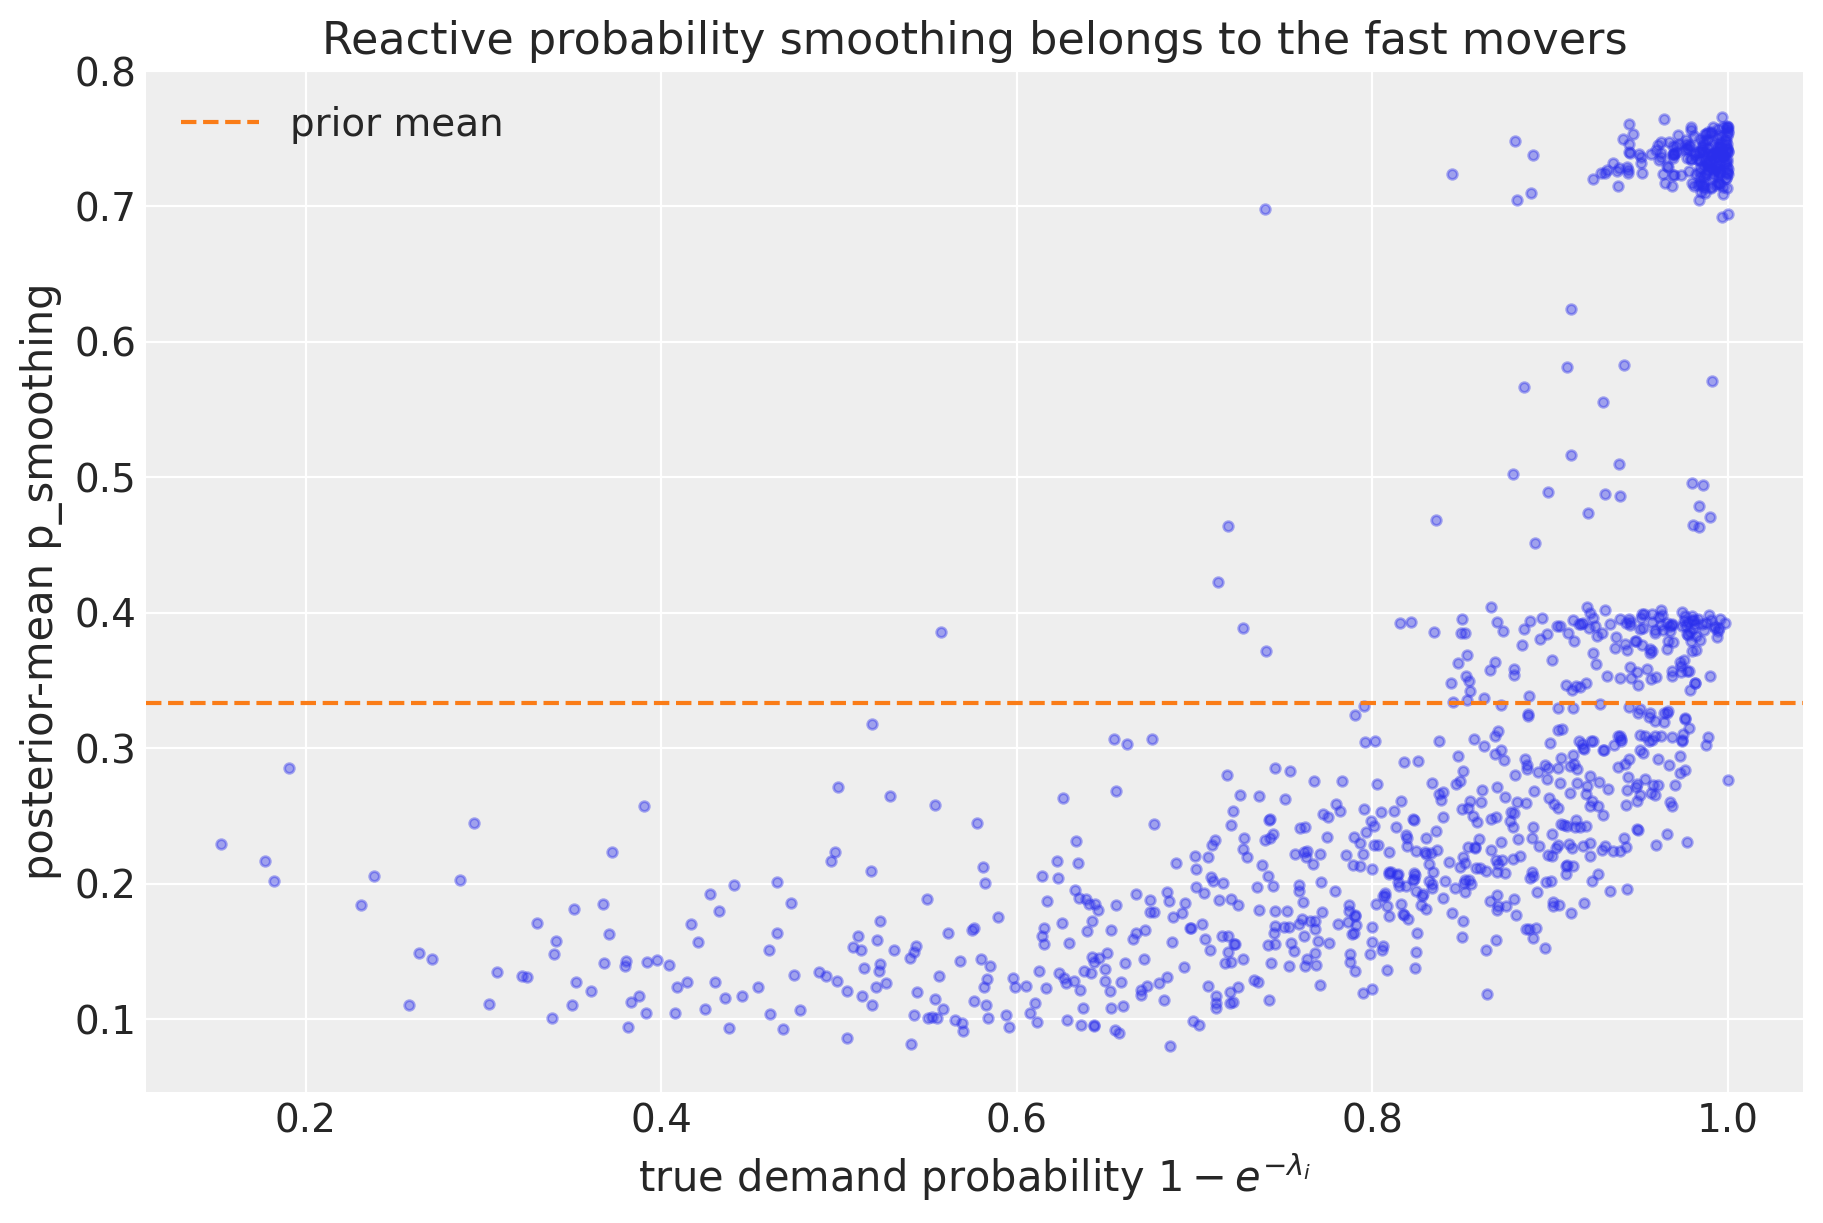

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))
p_true_all = 1 - np.exp(-lam)
ax.scatter(p_true_all, p_sm, s=12, alpha=0.4, color="C0")
ax.axhline(prior_mean, color="C1", ls="--", label="prior mean")
ax.legend(loc="upper left")
ax.set(
    title="Reactive probability smoothing belongs to the fast movers",
    xlabel=r"true demand probability $1 - e^{-\lambda_i}$",
    ylabel="posterior-mean p_smoothing",
);

In [14]:
high_sm = p_sm > 0.55
print(f"series with posterior-mean p_smoothing above 0.55: {int(high_sm.sum())}")
print(f"  their mean true demand probability:      {float(p_true_all[high_sm].mean()):.2f}")
print(f"  remaining series' mean true probability: {float(p_true_all[~high_sm].mean()):.2f}")

series with posterior-mean p_smoothing above 0.55: 204
  their mean true demand probability:      0.98
  remaining series' mean true probability: 0.78


## In-sample fit

For the in-sample story we plot the posterior of the `"rate"` site, the expected *sales* per period $a_t \hat{z}_{t-1} \hat{p}_{t-1}$, for five example series spanning the panel from fast to slow movers. The availability mask is visible twice in every panel: the rate drops to exactly zero in every shaded stock-out (no sales can happen off the shelf), and between stock-outs it moves gently as the smoothed components track the data.

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(


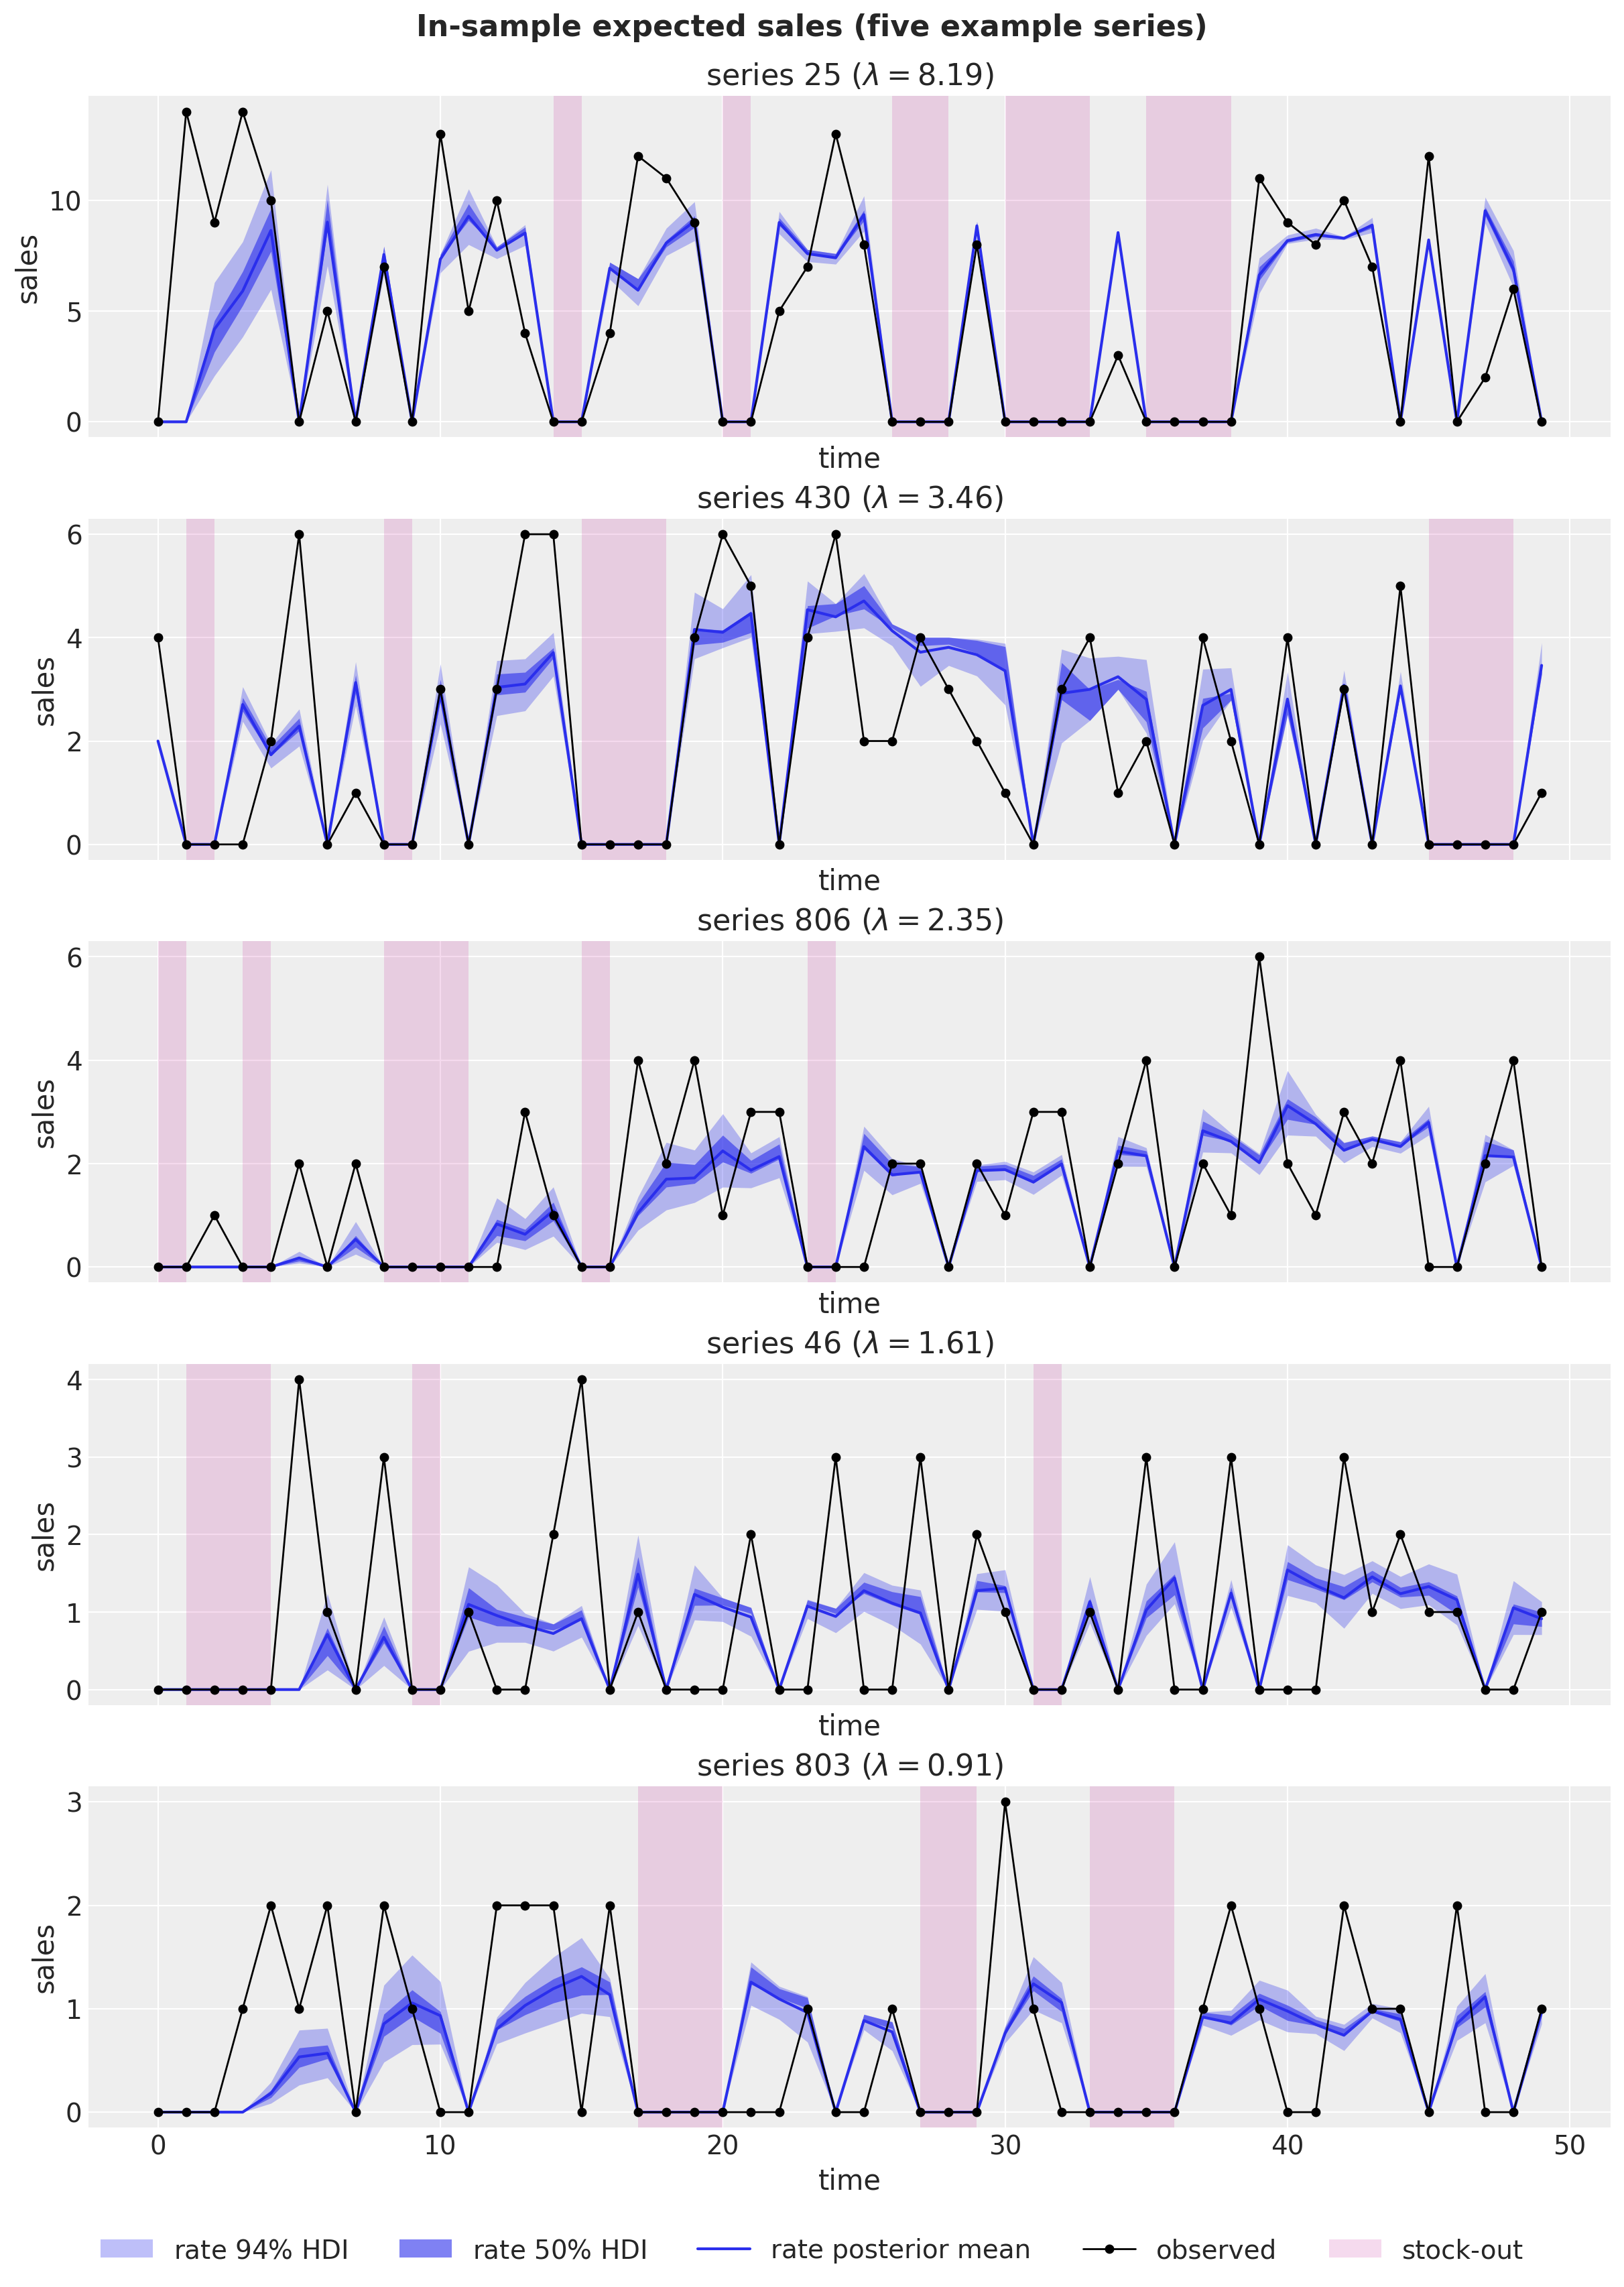

In [15]:
rate_draws = stacked_draws(tree["posterior"], "rate")

insample_series = display_series[::2]
insample_labels = [f"series {i}" for i in insample_series]
idata_rate = predictions_to_datatree(
    rate_draws[:, :, insample_series], t_train.astype(float), insample_labels
)
pc = az.plot_lm(
    idata_rate,
    y="obs",
    x="t",
    plot_dim="time",
    ci_kind="hdi",
    ci_prob=hdi_probs,
    smooth=False,
    point_estimate="mean",
    visuals={
        "ci_band": {"color": "C0"},
        "observed_scatter": False,
        "pe_line": {"color": "C0", "alpha": 1.0, "width": 1.5},
    },
    aes={"alpha": ["prob"]},
    alpha=hdi_alphas,
    col_wrap=1,
    figure_kwargs={"figsize": (12, 16), "sharex": True},
)
axes = pc.viz["plot"]["t"]
for label, i in zip(insample_labels, insample_series, strict=True):
    ax = axes.sel(series=label).item()
    (obs_line,) = ax.plot(
        t_train, np.asarray(train_data[:, i]), "o-", color="black", lw=1, ms=4, label="observed"
    )
    shade = shade_stockouts(ax, t_train, np.asarray(available_train[:, i]))
    ax.set(title=rf"series {i} ($\lambda = {lam[i]:.2f}$)", xlabel="time", ylabel="sales")
bands = pc.viz["ci_band"]["t"]
band_94 = bands.sel(series=insample_labels[0], prob=0.94).item()
band_50 = bands.sel(series=insample_labels[0], prob=0.5).item()
band_94.set_label(hdi_label(0.94, prefix="rate "))
band_50.set_label(hdi_label(0.5, prefix="rate "))
pe_line = pc.viz["pe_line"]["t"].sel(series=insample_labels[0]).item()
pe_line.set_label("rate posterior mean")
fig = pc.viz["figure"].item()
fig.legend(
    handles=[band_94, band_50, pe_line, obs_line, shade],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=5,
)
fig.suptitle(
    "In-sample expected sales (five example series)", fontsize=16, fontweight="bold", y=1.02
);

At first glance this fit can look poor: the blue line runs well below the observed spikes and above the many zeros, and its narrow bands cover almost none of the black dots. That is exactly how it should look. The plotted `"rate"` is the model's *expected* sales per period, a smoothed conditional mean, while each observation is a single draw from a very skewed intermittent distribution: mostly zeros, occasionally a spike several times the mean. A mean that ran through the spikes would not be a better fit; it would be chasing Poisson noise the model is deliberately averaging over (this is the same reason a constant $\lambda$ is the best possible point forecast for an i.i.d. Poisson series, however jagged its draws look). The bands are narrow for the same reason: they carry only parameter uncertainty about the smoothed level, not the observation noise around it. The honest question, "does the model's *predictive distribution* cover the data?", is answered on the test window below, where the posterior predictive (which does include the observation noise and the zero-inflation from demand gaps and stock-outs) is scored with CRPS and its empirical coverage.

### The demand probability

The probability path is where the innovation lives, so we look at it for the series with the *longest* stock-out run in the training window. The figure has a few moving parts, so here is how to read it:

- The path starts at the agnostic initialization $\hat{p}_0 = 0.5$ and is plotted as a posterior *band*, not a single line: the smoothing parameter $\beta$ is uncertain, and every recursion step inherits that uncertainty, so the band is the posterior over the whole trajectory.
- The short vertical rug marks at the bottom are the observed demand events. Each one pulls the estimate up by $\beta (1 - \hat{p}_t)$; each *on-shelf* zero decays it by a factor $(1 - \beta)$. This is plain TSB behavior, and between stock-outs the path does exactly that, wiggling around the series' true demand probability $1 - e^{-\lambda}$ (dashed line, a ground-truth quantity the model never sees).
- Through the shaded stock-out runs the availability-gated estimate stays exactly **frozen**: a zero the customer never had a chance to break carries no demand information, so the recursion skips it.
- The dashed blue line is the counterfactual that makes the freeze visible: the same recursion with the same fitted smoothing parameter, but with plain TSB's every-period updates, which read the enforced silence of a stock-out as vanishing demand. Every shaded run drags it down (the long mid-window run pulls it almost to zero), and because each of those artificial decays has to be earned back through subsequent demand events, the counterfactual spends essentially the whole window below the gated path. That persistent gap is exactly the downward bias the availability gate removes.

series 178: longest stock-out run in train = 9 periods, lambda = 2.07


/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(


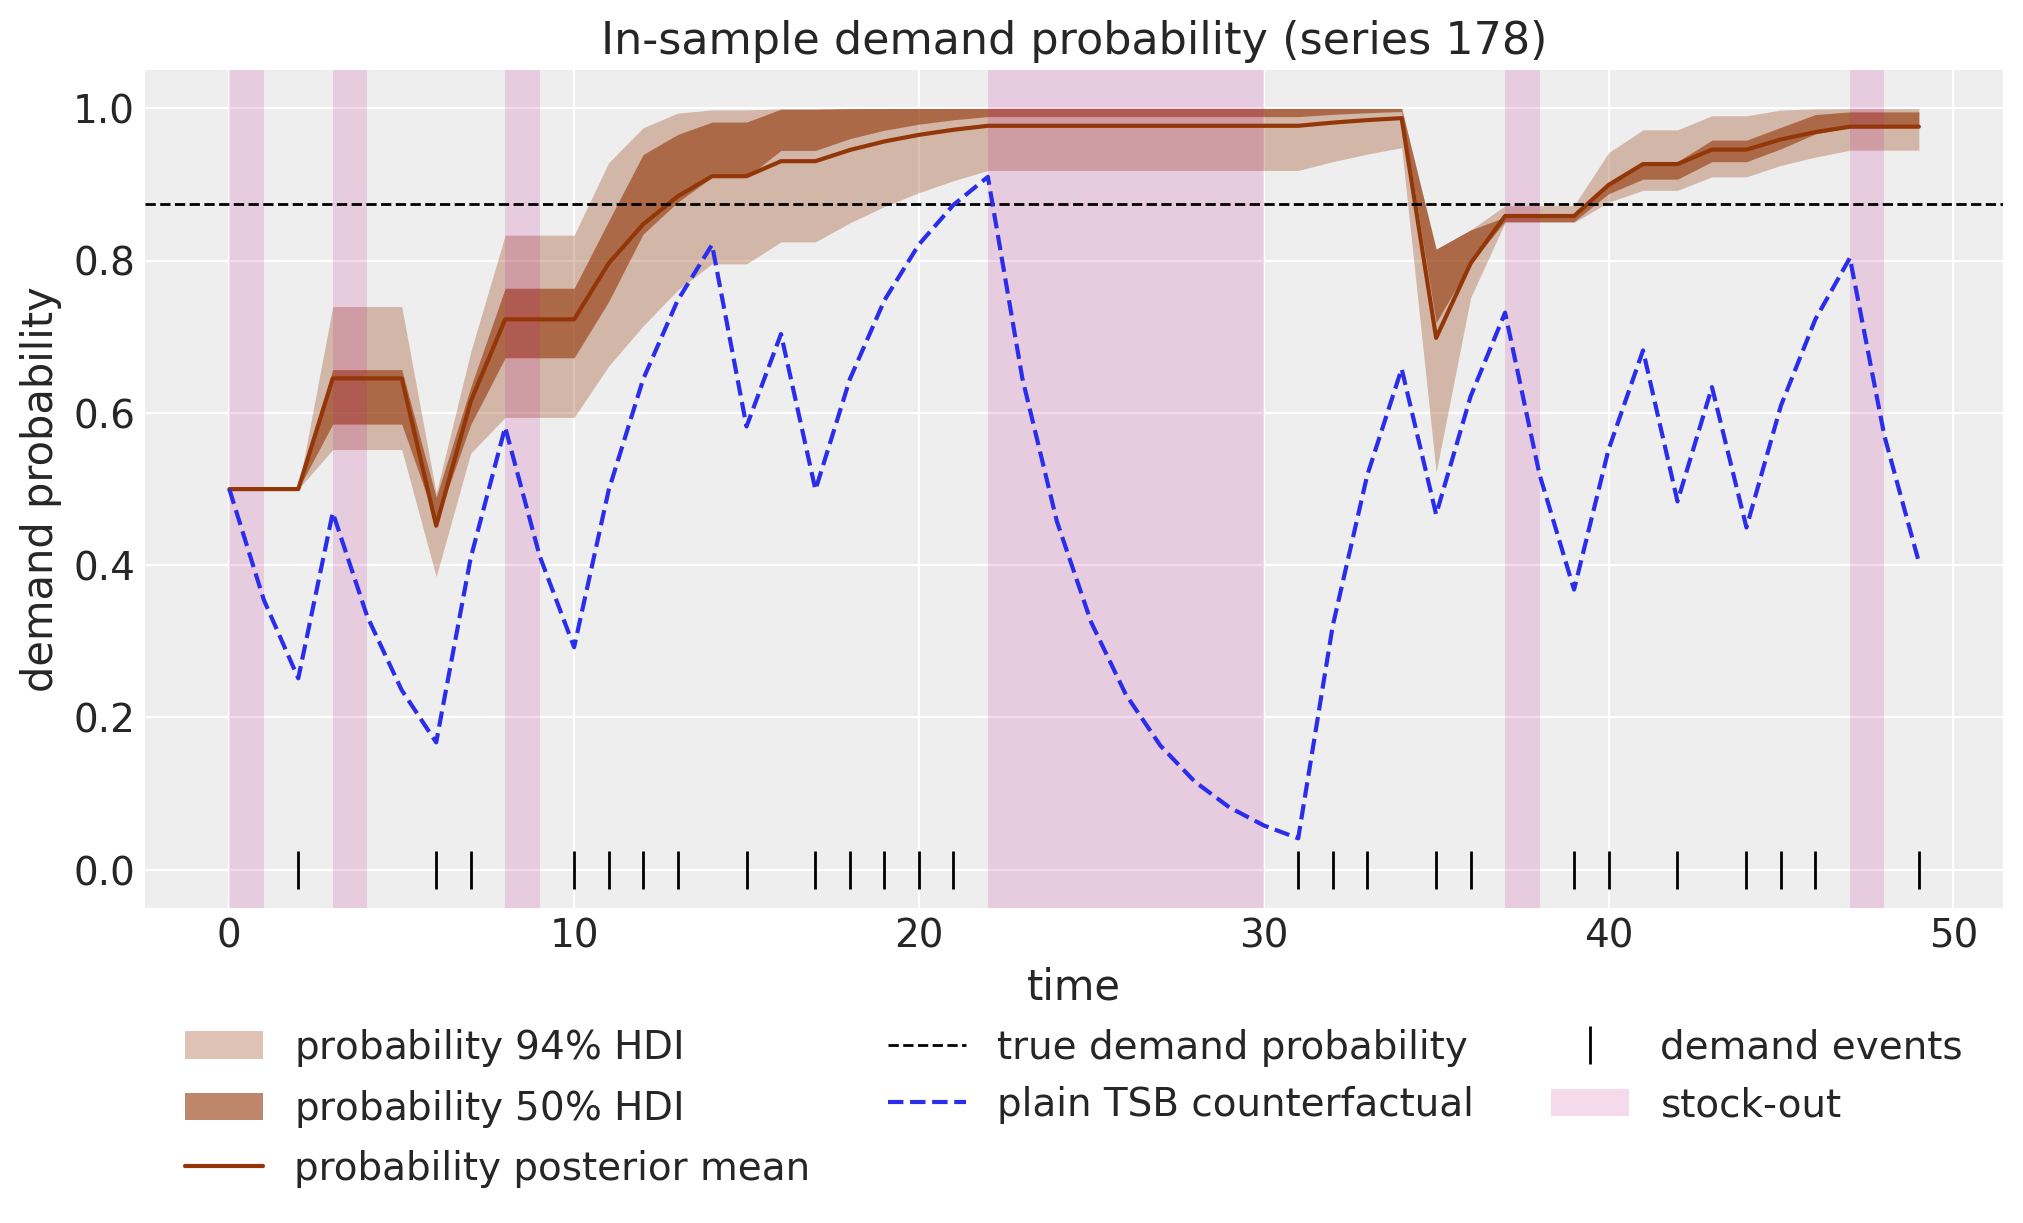

In [16]:
avail_train_np = np.asarray(available_train)
run = np.zeros(n_series)
longest = np.zeros(n_series)
for step in range(t_max_train):
    run = np.where(avail_train_np[step] == 0, run + 1, 0.0)
    longest = np.maximum(longest, run)
j = int(np.argmax(longest))
print(
    f"series {j}: longest stock-out run in train = {int(longest[j])} periods, "
    f"lambda = {lam[j]:.2f}"
)

prob_draws = stacked_draws(tree["posterior"], "prob")

ax, handles = plot_band_forecast(
    prob_draws[:, :, [j]],
    t_train.astype(float),
    "C4",
    label_prefix="probability ",
    figsize=(10.0, 6.0),
)
p_true_j = 1 - np.exp(-lam[j])
true_line = ax.axhline(p_true_j, color="black", ls="--", lw=1, label="true demand probability")

# Counterfactual: the same recursion with the fitted (posterior-mean) smoothing
# parameter but plain TSB's every-period updates, so stock-outs decay it too.
beta_j = float(p_sm[j])
demand_indicator_j = np.asarray(train_data[:, j] > 0, dtype=float)
plain_path = np.empty(t_max_train)
p_hat = 0.5
for step in range(t_max_train):
    plain_path[step] = p_hat
    p_hat = p_hat + beta_j * (demand_indicator_j[step] - p_hat)
(plain_line,) = ax.plot(
    t_train, plain_path, color="C0", ls="--", lw=1.5, label="plain TSB counterfactual"
)

event_times = t_train[np.asarray(train_data[:, j] > 0)]
(rug,) = ax.plot(
    event_times,
    np.zeros_like(event_times, dtype=float),
    "|",
    color="black",
    ms=14,
    label="demand events",
)
shade = shade_stockouts(ax, t_train, avail_train_np[:, j])
ax.legend(
    handles=[*handles, true_line, plain_line, rug, shade],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
ax.set(
    title=f"In-sample demand probability (series {j})",
    xlabel="time",
    ylabel="demand probability",
);

## Forecast

The `predictions` group of the tree already holds the out-of-sample draws of the `"forecast"` site under the **realized-availability scenario**: the test window's actual stock-out pattern rode in on the covariates, so the forecast predicts zero sales in the periods the product is genuinely off the shelf and $\hat{z} \hat{p}$ plus noise elsewhere. That is the right object to score against the observed test sales, which we do panel-wide with the CRPS and the central-interval coverages.

In [17]:
forecast_pp = stacked_draws(tree["predictions"], "obs")
crps_test = float(eval_crps(forecast_pp, np.asarray(test_data)))
cov_50 = float(eval_coverage(forecast_pp, np.asarray(test_data), alpha=0.5))
cov_94 = float(eval_coverage(forecast_pp, np.asarray(test_data), alpha=0.94))
print(f"panel test CRPS (realized availability): {crps_test:.4f}")
print(f"empirical 50% coverage: {cov_50:.2f}  (nominal 0.50)")
print(f"empirical 94% coverage: {cov_94:.2f}  (nominal 0.94)")

panel test CRPS (realized availability): 0.5471
empirical 50% coverage: 0.70  (nominal 0.50)
empirical 94% coverage: 0.98  (nominal 0.94)


/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(


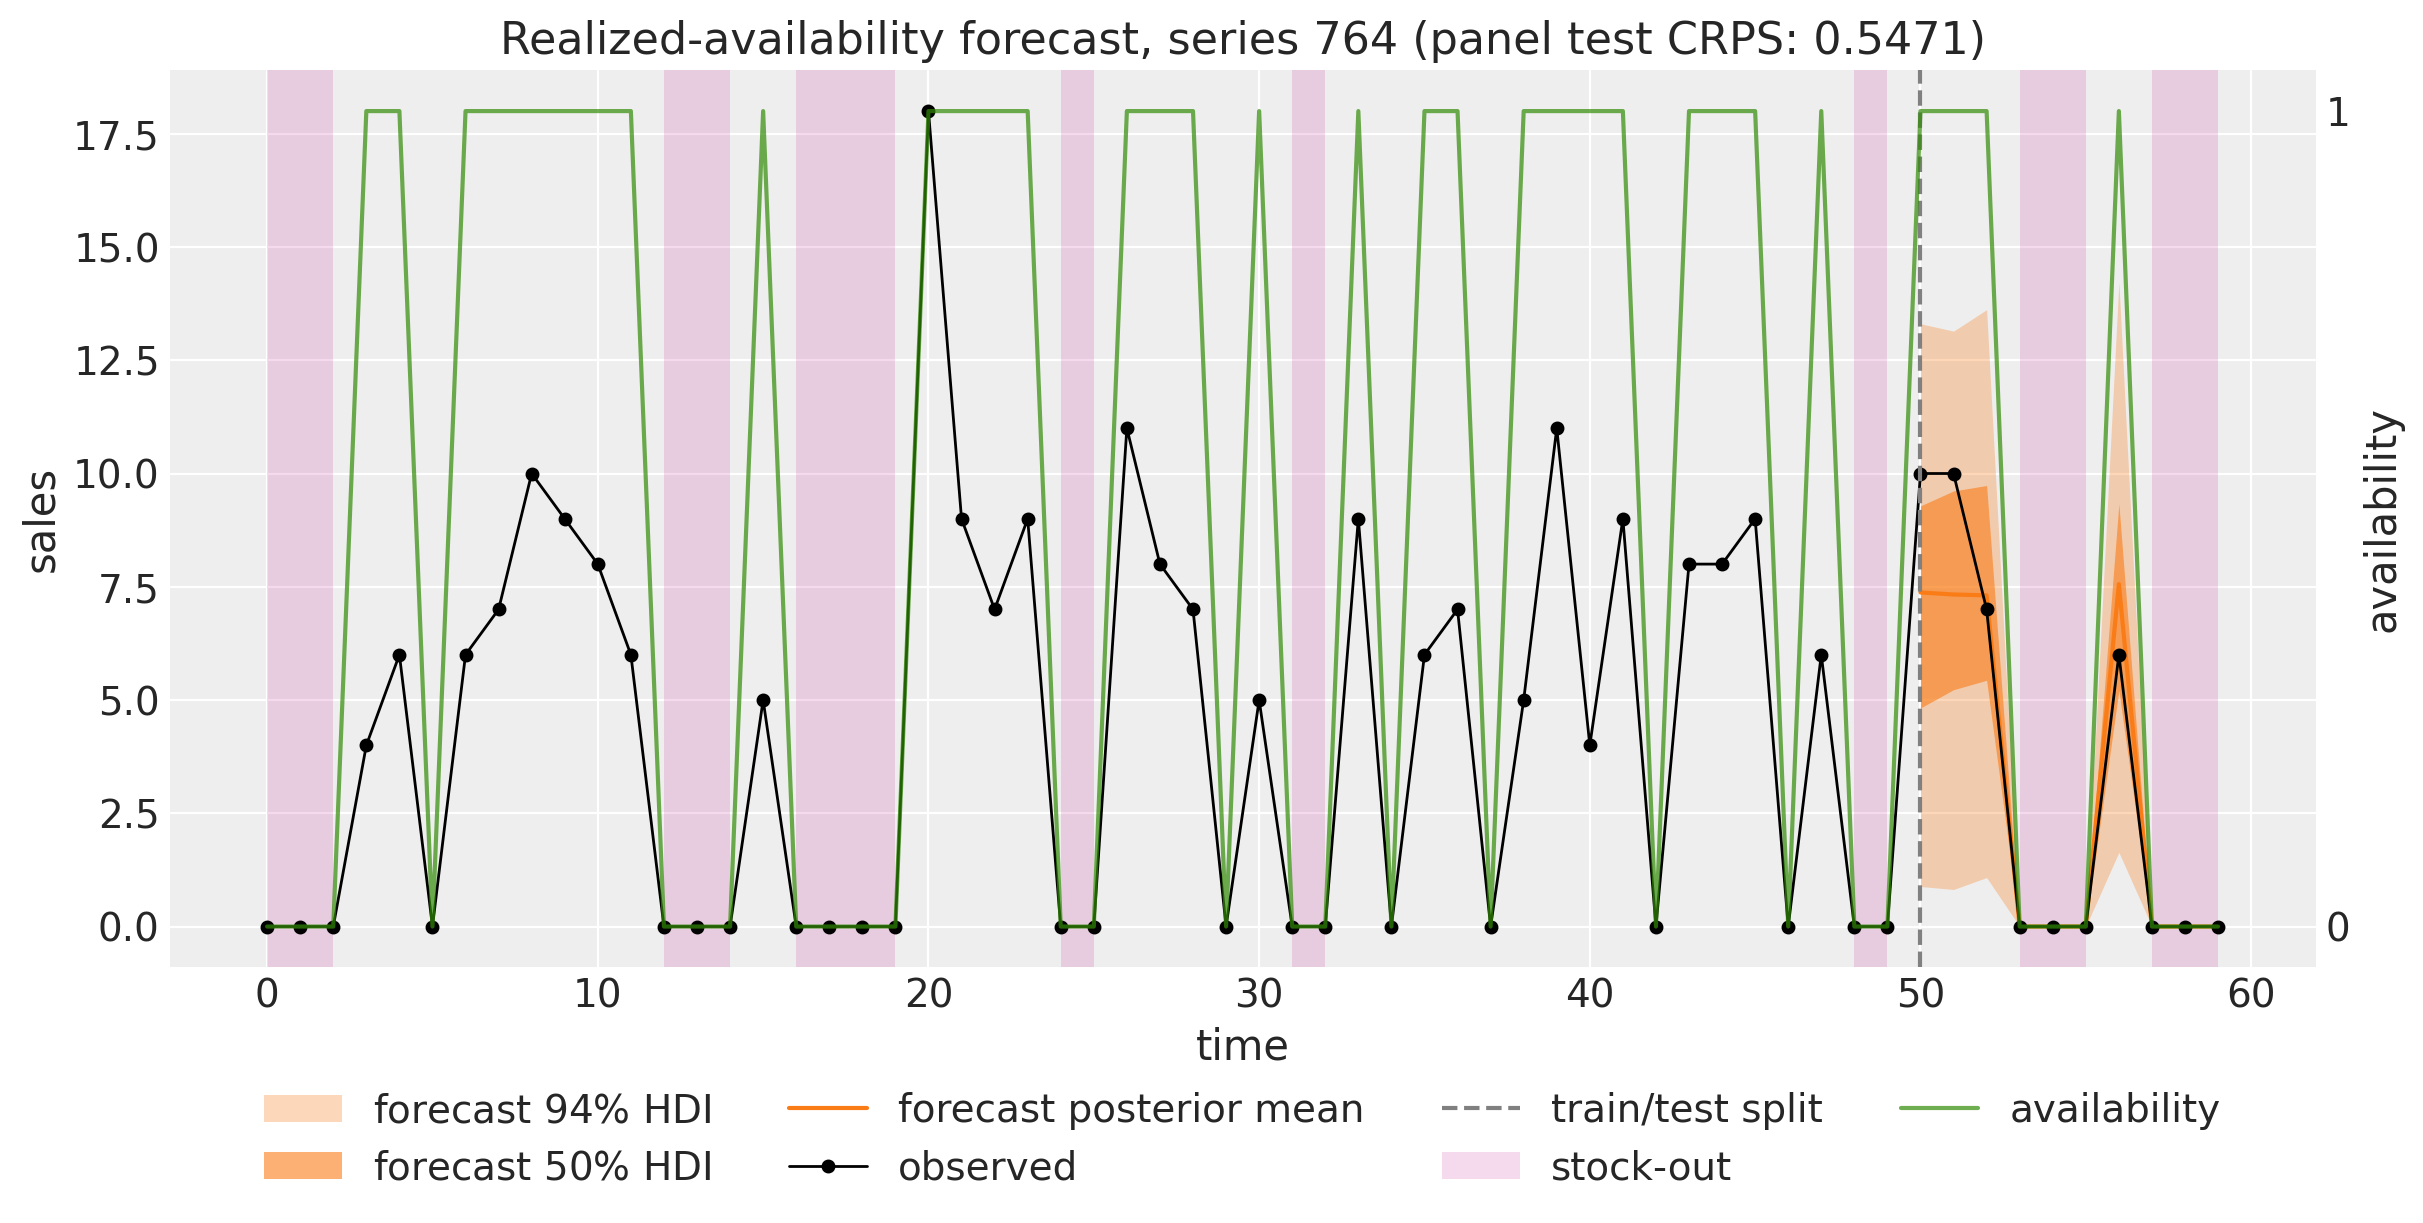

In [18]:
def add_availability_axis(ax: Axes, t_axis: np.ndarray, available: np.ndarray) -> Artist:
    """Draw the availability series on a right-hand twin axis, as in the blog post.

    Parameters
    ----------
    ax
        The axes holding the sales-scale plot.
    t_axis
        Time values of length ``time``.
    available
        The 0/1 availability values along ``t_axis``.

    Returns
    -------
    Artist
        The availability line, labeled ``"availability"`` for legends.
    """
    ax_avail = ax.twinx()
    (avail_line,) = ax_avail.plot(
        t_axis, np.asarray(available), color="C2", lw=1.5, alpha=0.7, label="availability"
    )
    ax_avail.set(ylabel="availability", yticks=[0, 1])
    ax_avail.grid(False)
    return avail_line


i = example_series
ax, handles = plot_band_forecast(
    forecast_pp[:, :, [i]],
    t_test.astype(float),
    "C1",
    label_prefix="forecast ",
    observed=np.asarray(test_data[:, [i]]),
)
(obs_line,) = ax.plot(
    t, np.asarray(panel.sales[:, i]), "o-", color="black", lw=1, ms=4, label="observed"
)
split_line = ax.axvline(t_max_train, color="gray", ls="--", label="train/test split")
shade = shade_stockouts(ax, t, np.asarray(panel.available[:, i]))
avail_line = add_availability_axis(ax, t, np.asarray(panel.available[:, i]))
ax.legend(
    handles=[*handles, obs_line, split_line, shade, avail_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=4,
)
ax.set(
    title=f"Realized-availability forecast, series {i} (panel test CRPS: {crps_test:.4f})",
    xlabel="time",
    ylabel="sales",
);

The forecast band pinches to zero inside the shaded test stock-outs and re-opens when the product returns to the shelf: the availability input is doing the work directly in the forecast path.

### Zeros at the forecast origin do not drag the forecast down

Here is the single most important picture in this notebook. Consider a series whose training window *ends* in a stock-out run: the last thing the model sees before forecasting is a string of zeros. Every classical intermittent-demand method reads that string as evidence that demand is dying, plain TSB decays its demand probability by $(1 - \beta)$ per period through the entire run, and its forecast opens *low* accordingly. But these zeros carry no demand information at all, because the product was off the shelf. We select the series with the longest such trailing run among the fast movers whose test window is mostly on the shelf, so the difference is visible in the observed data.

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(


series 41: last 5 training periods are stock-outs, lambda = 5.12, latent demand lost in the run = 33 units


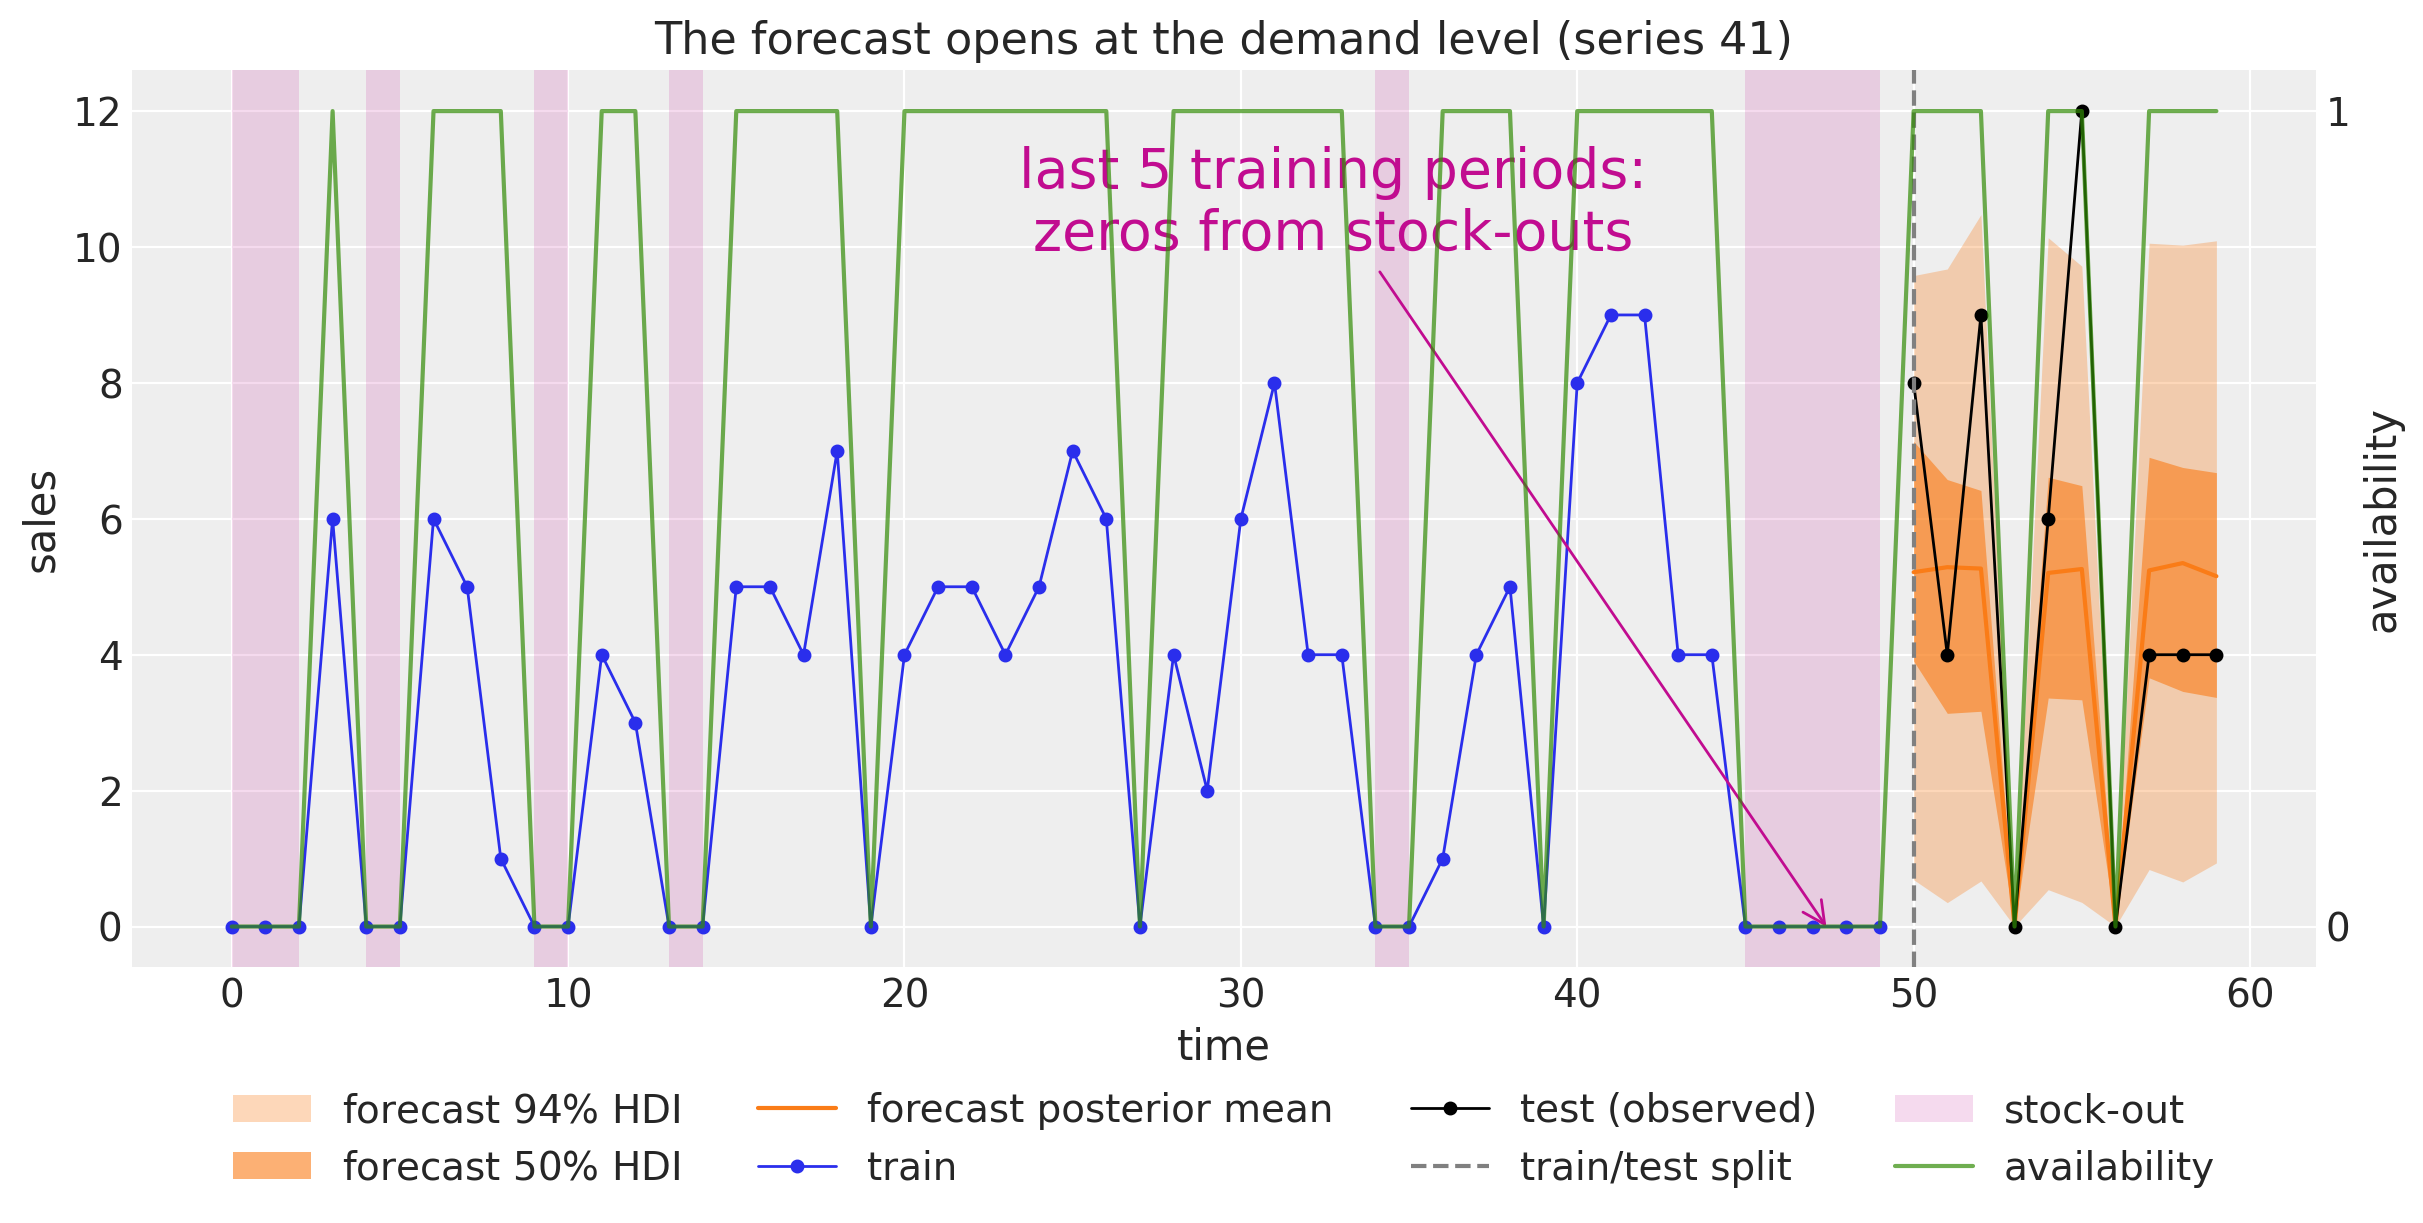

In [19]:
trailing_run = np.cumprod(avail_train_np[::-1] == 0, axis=0).sum(axis=0)
hero_candidates = (lam > np.median(lam)) & (np.asarray(available_test).mean(axis=0) >= 0.8)
k = int(np.argmax(np.where(hero_candidates, trailing_run, -1)))
run_k = int(trailing_run[k])
lost_k = float(panel.demand[t_max_train - run_k : t_max_train, k].sum())
print(
    f"series {k}: last {run_k} training periods are stock-outs, lambda = {lam[k]:.2f}, "
    f"latent demand lost in the run = {lost_k:.0f} units"
)

ax, handles = plot_band_forecast(
    forecast_pp[:, :, [k]],
    t_test.astype(float),
    "C1",
    label_prefix="forecast ",
    observed=np.asarray(test_data[:, [k]]),
)
(train_line,) = ax.plot(
    t_train, np.asarray(train_data[:, k]), "o-", color="C0", lw=1, ms=4, label="train"
)
(test_line,) = ax.plot(
    t_test, np.asarray(test_data[:, k]), "o-", color="black", lw=1, ms=4, label="test (observed)"
)
split_line = ax.axvline(t_max_train, color="gray", ls="--", label="train/test split")
shade = shade_stockouts(ax, t, np.asarray(panel.available[:, k]))
avail_line = add_availability_axis(ax, t, np.asarray(panel.available[:, k]))
ax.annotate(
    f"last {run_k} training periods:\nzeros from stock-outs",
    xy=(t_max_train - run_k / 2, 0.04),
    xycoords=ax.get_xaxis_transform(),
    xytext=(0.55, 0.8),
    textcoords="axes fraction",
    ha="center",
    fontsize=20,
    arrowprops={"arrowstyle": "->", "color": "C3"},
    color="C3",
)
ax.legend(
    handles=[*handles, train_line, test_line, split_line, shade, avail_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=4,
)
ax.set(
    title=f"The forecast opens at the demand level (series {k})",
    xlabel="time",
    ylabel="sales",
);

The last observations before the forecast origin are all zeros, and yet the forecast does **not** open at zero: it opens right at the series' demand level, and the observed test sales (black) immediately confirm it. The model can do this because the availability gate froze the demand-probability estimate through the shaded run, so at the origin $\hat{p}$ still remembers what demand looked like the last time the product was actually on the shelf. The green availability line makes the mechanism visible: the forecast bands pinch toward zero exactly where availability drops, and nowhere else. We return to this series at the end of the notebook to show what plain TSB would have done in its place.

### Component forecasts

As in the sibling notebooks, we sample the two component predictives directly with `Predictive`, requesting the `"z_forecast"` and `"p_forecast"` deterministic sites, and plot them side by side with a single faceted `plot_lm` call. The posterior draws come from [`draw_posterior`](https://juanitorduz.github.io/numpyro_forecast/reference/functional.posterior.draw_posterior.html) (they are reused for the scenario forecasts below), chunked and moved to host for the same memory reasons as the tree export. The demand-size component predicts the size of the next demand; the demand-probability component predicts the chance an *on-shelf* period sees demand, which is precisely what makes multiplying by a chosen future availability meaningful.

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(


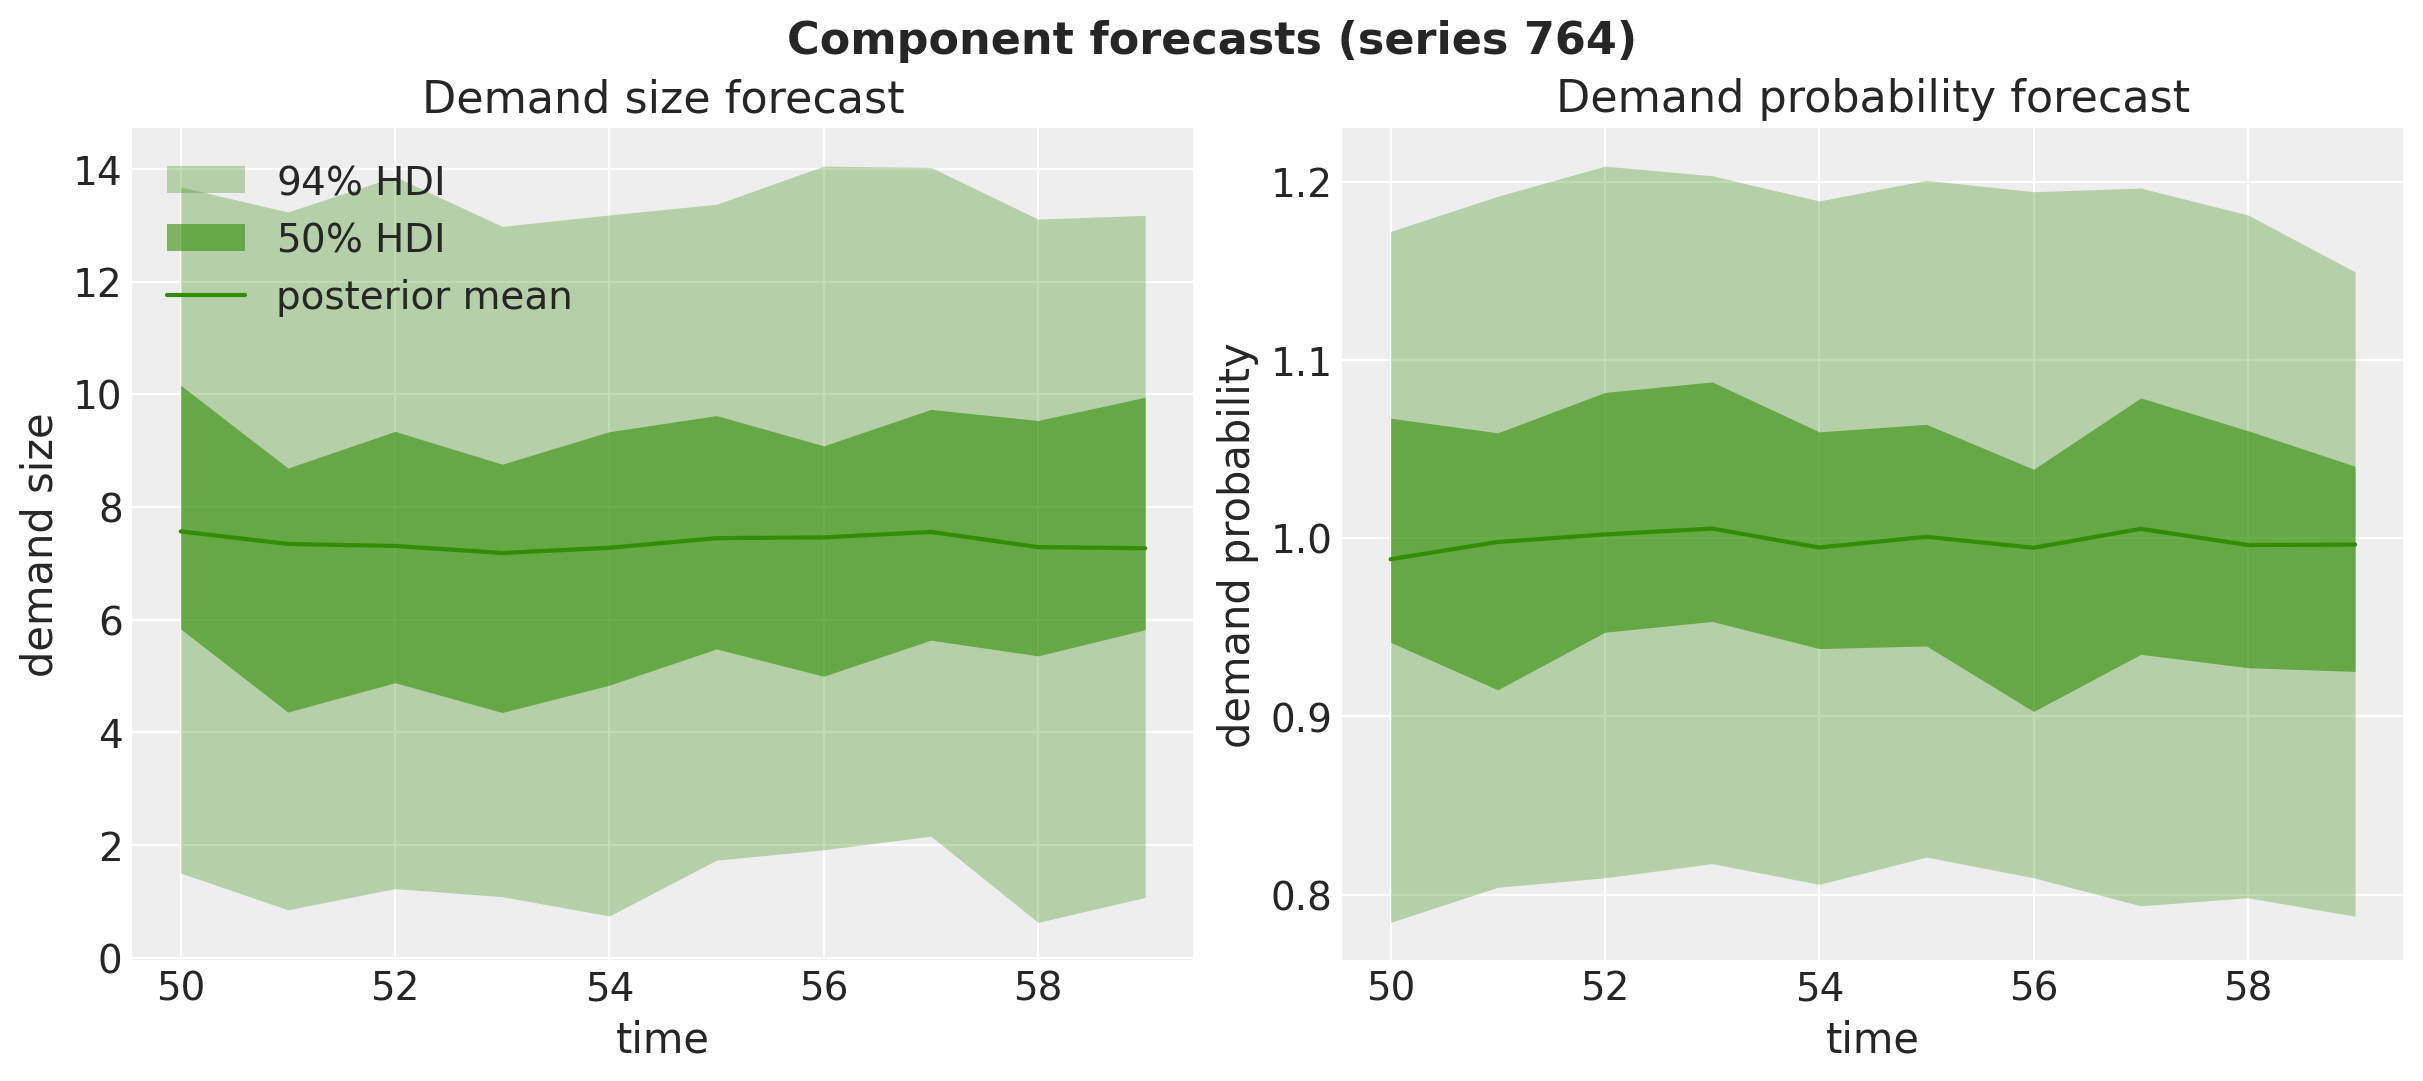

In [20]:
rng_key, rng_subkey = random.split(rng_key)
post = draw_posterior(rng_subkey, fit, num_samples=1_000, batch_size=250, device="host")

rng_key, rng_subkey = random.split(rng_key)
predictive = Predictive(
    model,
    posterior_samples={k: v[:500] for k, v in post.items()},
    return_sites=["z_forecast", "p_forecast"],
)
component_draws = predictive(rng_subkey, covariates_full, train_data)

i = example_series
components = np.concatenate(
    [
        np.asarray(component_draws["z_forecast"])[:, :, [i]],
        np.asarray(component_draws["p_forecast"])[:, :, [i]],
    ],
    axis=-1,
)

idata_components = predictions_to_datatree(
    components, t_test.astype(float), ["demand size", "demand probability"]
)
pc = az.plot_lm(
    idata_components,
    y="obs",
    x="t",
    plot_dim="time",
    ci_kind="hdi",
    ci_prob=hdi_probs,
    smooth=False,
    point_estimate="mean",
    visuals={
        "ci_band": {"color": "C2"},
        "observed_scatter": False,
        "pe_line": {"color": "C2", "alpha": 1.0, "width": 1.5},
    },
    aes={"alpha": ["prob"]},
    alpha=hdi_alphas,
    figure_kwargs={"figsize": (12, 5), "sharex": True},
)
axes = pc.viz["plot"]["t"]
axes.sel(series="demand size").item().set(
    title="Demand size forecast", xlabel="time", ylabel="demand size"
)
axes.sel(series="demand probability").item().set(
    title="Demand probability forecast", xlabel="time", ylabel="demand probability"
)
bands = pc.viz["ci_band"]["t"]
band_94 = bands.sel(series="demand size", prob=0.94).item()
band_50 = bands.sel(series="demand size", prob=0.5).item()
band_94.set_label(hdi_label(0.94))
band_50.set_label(hdi_label(0.5))
pe_line = pc.viz["pe_line"]["t"].sel(series="demand size").item()
pe_line.set_label("posterior mean")
axes.sel(series="demand size").item().legend(handles=[band_94, band_50, pe_line], loc="upper left")
fig = pc.viz["figure"].item()
fig.suptitle(f"Component forecasts (series {i})", fontsize=16, fontweight="bold", y=1.05);

### Scenario planning: full availability

Here is the payoff of modeling availability as an input. The tree above answers "what will we *sell* given the availability we actually had"; replenishment planning needs "what would we sell **if the product were always on the shelf**". With the functional API that is one more [`forecast`](https://juanitorduz.github.io/numpyro_forecast/reference/functional.prediction.forecast.html) call on the *same* posterior draws, feeding covariates whose future availability rows are all ones, and one [`add_forecast_groups`](https://juanitorduz.github.io/numpyro_forecast/reference/convert.add_forecast_groups.html) call to package the draws as the `predictions` group of a sibling tree (the groups it copies from `tree` are shared, so this costs no memory beyond the new forecast).

In [21]:
covariates_full_ones = jnp.stack(
    [
        sales_input_full,
        jnp.concatenate([available_train, jnp.ones_like(available_test)], axis=0),
    ],
    axis=0,
)

rng_key, rng_subkey = random.split(rng_key)
fc_full = forecast(
    rng_subkey, model, post, train_data, covariates_full_ones, batch_size=250, device="host"
)
tree_full = add_forecast_groups(
    tree, np.asarray(fc_full), covariates_full_ones[:, t_max_train:, :]
)
forecast_full = stacked_draws(tree_full["predictions"], "obs")
print(f"full-availability forecast draws: {forecast_full.shape}")

full-availability forecast draws: (1000, 10, 1000)


We compare the two scenarios where they differ most visibly: the total demand across the whole panel, period by period. Under realized availability the forecast tracks the observed total *sales*; under full availability it recovers the total latent *demand*, whose ground truth (the sum of the $\lambda_i$, dashed line) the model has never seen. Roughly $40\%$ of demand is invisible in any single period's sales, and the availability-aware model reconstructs it.

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(


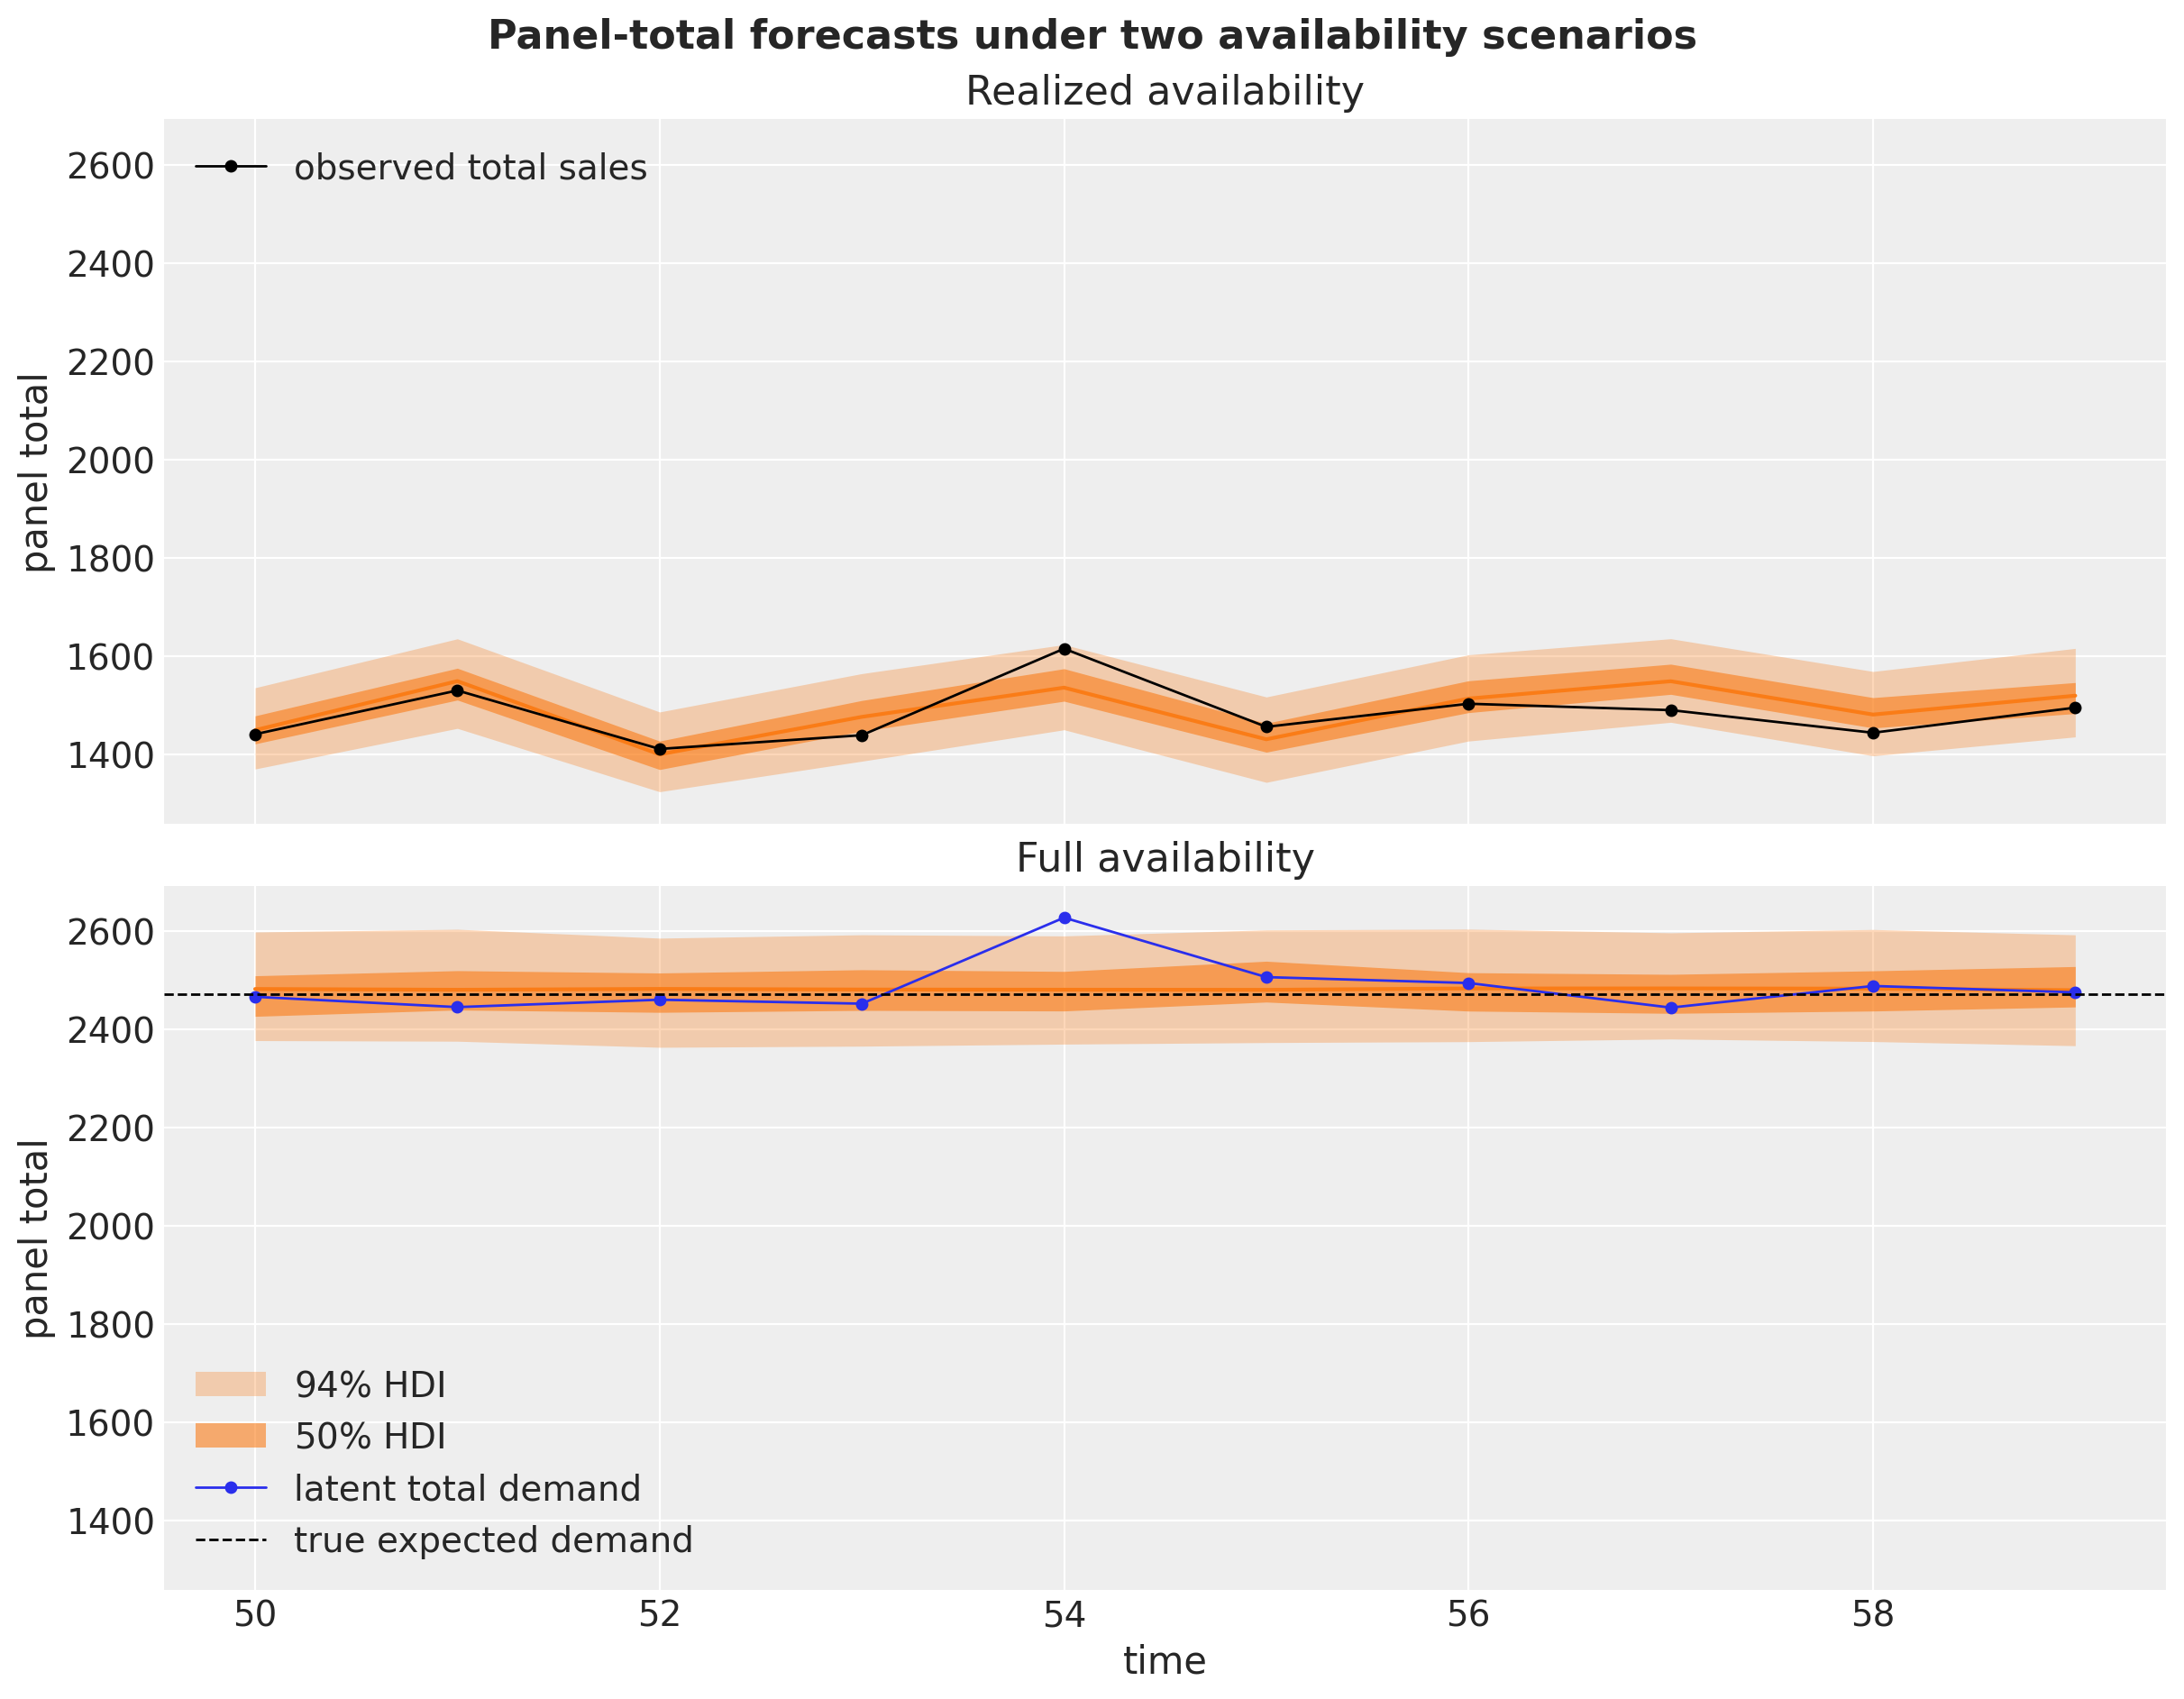

In [22]:
totals = np.stack(
    [forecast_pp.sum(axis=-1), forecast_full.sum(axis=-1)], axis=-1
)  # (sample, time, scenario)
expected_total = float(lam.sum())
scenario_labels = ["realized availability", "full availability"]

idata_totals = predictions_to_datatree(totals, t_test.astype(float), scenario_labels)
pc = az.plot_lm(
    idata_totals,
    y="obs",
    x="t",
    plot_dim="time",
    ci_kind="hdi",
    ci_prob=hdi_probs,
    smooth=False,
    point_estimate="mean",
    visuals={
        "ci_band": {"color": "C1"},
        "observed_scatter": False,
        "pe_line": {"color": "C1", "alpha": 1.0, "width": 1.5},
    },
    aes={"alpha": ["prob"]},
    alpha=hdi_alphas,
    col_wrap=1,
    figure_kwargs={"figsize": (12, 9), "sharex": True, "sharey": True},
)
axes = pc.viz["plot"]["t"]
ax_realized = axes.sel(series="realized availability").item()
ax_full = axes.sel(series="full availability").item()
(sales_line,) = ax_realized.plot(
    t_test,
    np.asarray(test_data.sum(axis=-1)),
    "o-",
    color="black",
    lw=1,
    ms=4,
    label="observed total sales",
)
(demand_line,) = ax_full.plot(
    t_test,
    np.asarray(panel.demand[t_max_train:].sum(axis=-1)),
    "o-",
    color="C0",
    lw=1,
    ms=4,
    label="latent total demand",
)
truth_line = ax_full.axhline(
    expected_total, color="black", ls="--", lw=1, label="true expected demand"
)
ax_realized.set(title="Realized availability", xlabel="", ylabel="panel total")
ax_full.set(title="Full availability", xlabel="time", ylabel="panel total")
bands = pc.viz["ci_band"]["t"]
band_94 = bands.sel(series="full availability", prob=0.94).item()
band_50 = bands.sel(series="full availability", prob=0.5).item()
band_94.set_label(hdi_label(0.94))
band_50.set_label(hdi_label(0.5))
ax_realized.legend(handles=[sales_line], loc="upper left")
ax_full.legend(handles=[band_94, band_50, demand_line, truth_line], loc="lower left")
fig = pc.viz["figure"].item()
fig.suptitle(
    "Panel-total forecasts under two availability scenarios",
    fontsize=16,
    fontweight="bold",
    y=1.03,
);

In [23]:
mean_total_realized = float(totals[..., 0].mean())
mean_total_full = float(totals[..., 1].mean())
print(f"true expected demand per period (sum of lambdas):  {expected_total:,.1f}")
print(
    f"expected sales per period at 60% availability:     {availability_rate * expected_total:,.1f}"
)
print(
    f"forecast total per period, realized availability:  {mean_total_realized:,.1f} "
    f"({mean_total_realized / expected_total:.0%} of expected demand)"
)
print(
    f"forecast total per period, full availability:      {mean_total_full:,.1f} "
    f"({mean_total_full / expected_total:.0%} of expected demand)"
)

true expected demand per period (sum of lambdas):  2,471.8
expected sales per period at 60% availability:     1,483.1
forecast total per period, realized availability:  1,490.4 (60% of expected demand)
forecast total per period, full availability:      2,481.3 (100% of expected demand)


How to read this figure:

- **Top panel (realized availability).** The forecast answers "how much will we *sell* under the stock-out pattern the test window actually had". The panel total wiggles period by period because a different random $40\%$ of the assortment is off the shelf each period, and the band tracks the observed total sales (black), which is the quantity this scenario should predict. Note that the model gets the *level* right without ever being told the availability rate: it learned each series' on-shelf demand and the covariates supply who is on the shelf when.
- **Bottom panel (full availability).** Same posterior, one covariate change: every product on the shelf over the whole horizon. The forecast jumps to the level of the *latent demand* (blue), the sales that would materialize with nothing censored, and its mean sits essentially on the true expected demand $\sum_i \lambda_i$ (dashed), a ground-truth quantity the model has never observed. This is the number a replenishment plan actually needs, and no amount of post-processing of the top panel produces it: scaling censored forecasts up by a global availability rate would miss which series were censored and by how much.
- **The vertical gap between the panels** is easy to read off because they share the y axis: it is the roughly $40\%$ of demand that stock-outs make invisible in any single period's sales. The printed totals below the figure quantify it: the realized-availability total sits near the expected *sales* level, while the full-availability total recovers the expected *demand* within a few percent.
- **Band widths.** The bands are much narrower, relative to the mean, than in the single-series forecasts above: summing $1{,}000$ series averages away the independent per-series noise, so what remains is mostly the (small, well-pooled) parameter uncertainty plus the availability pattern itself.

## Comparison with plain TSB

Since plain TSB is the special case $a_t \equiv 1$, comparing against it requires no second model: we refit the *same* model with an all-ones availability input, so its demand-probability component decays on every zero, stock-out or not. The synthetic setup then lets us do something a real dataset never allows: score both fits against the **known truth**. Each series' true on-shelf demand probability is $1 - e^{-\lambda_i}$, and we compare it with each fit's posterior-mean probability path, time-averaged over the second half of the training window to wash out the $\hat{p}_0 = 0.5$ transient.

In [24]:
covariates_train_ones = jnp.stack([train_data, jnp.ones_like(train_data)], axis=0)

rng_key, rng_subkey = random.split(rng_key)
fit_plain = fit_svi(
    rng_subkey,
    model,
    train_data,
    covariates_train_ones,
    optim=0.001,
    num_steps=10_000,
)
print(f"mean ELBO loss over the last 100 steps: {float(jnp.mean(fit_plain.losses[-100:])):,.0f}")

rng_key, rng_subkey = random.split(rng_key)
post_plain = draw_posterior(
    rng_subkey, fit_plain, num_samples=1_000, batch_size=250, device="host"
)

mean ELBO loss over the last 100 steps: 87,683


mean estimated / true demand probability, availability-aware: 0.99
mean estimated / true demand probability, plain TSB:          0.60


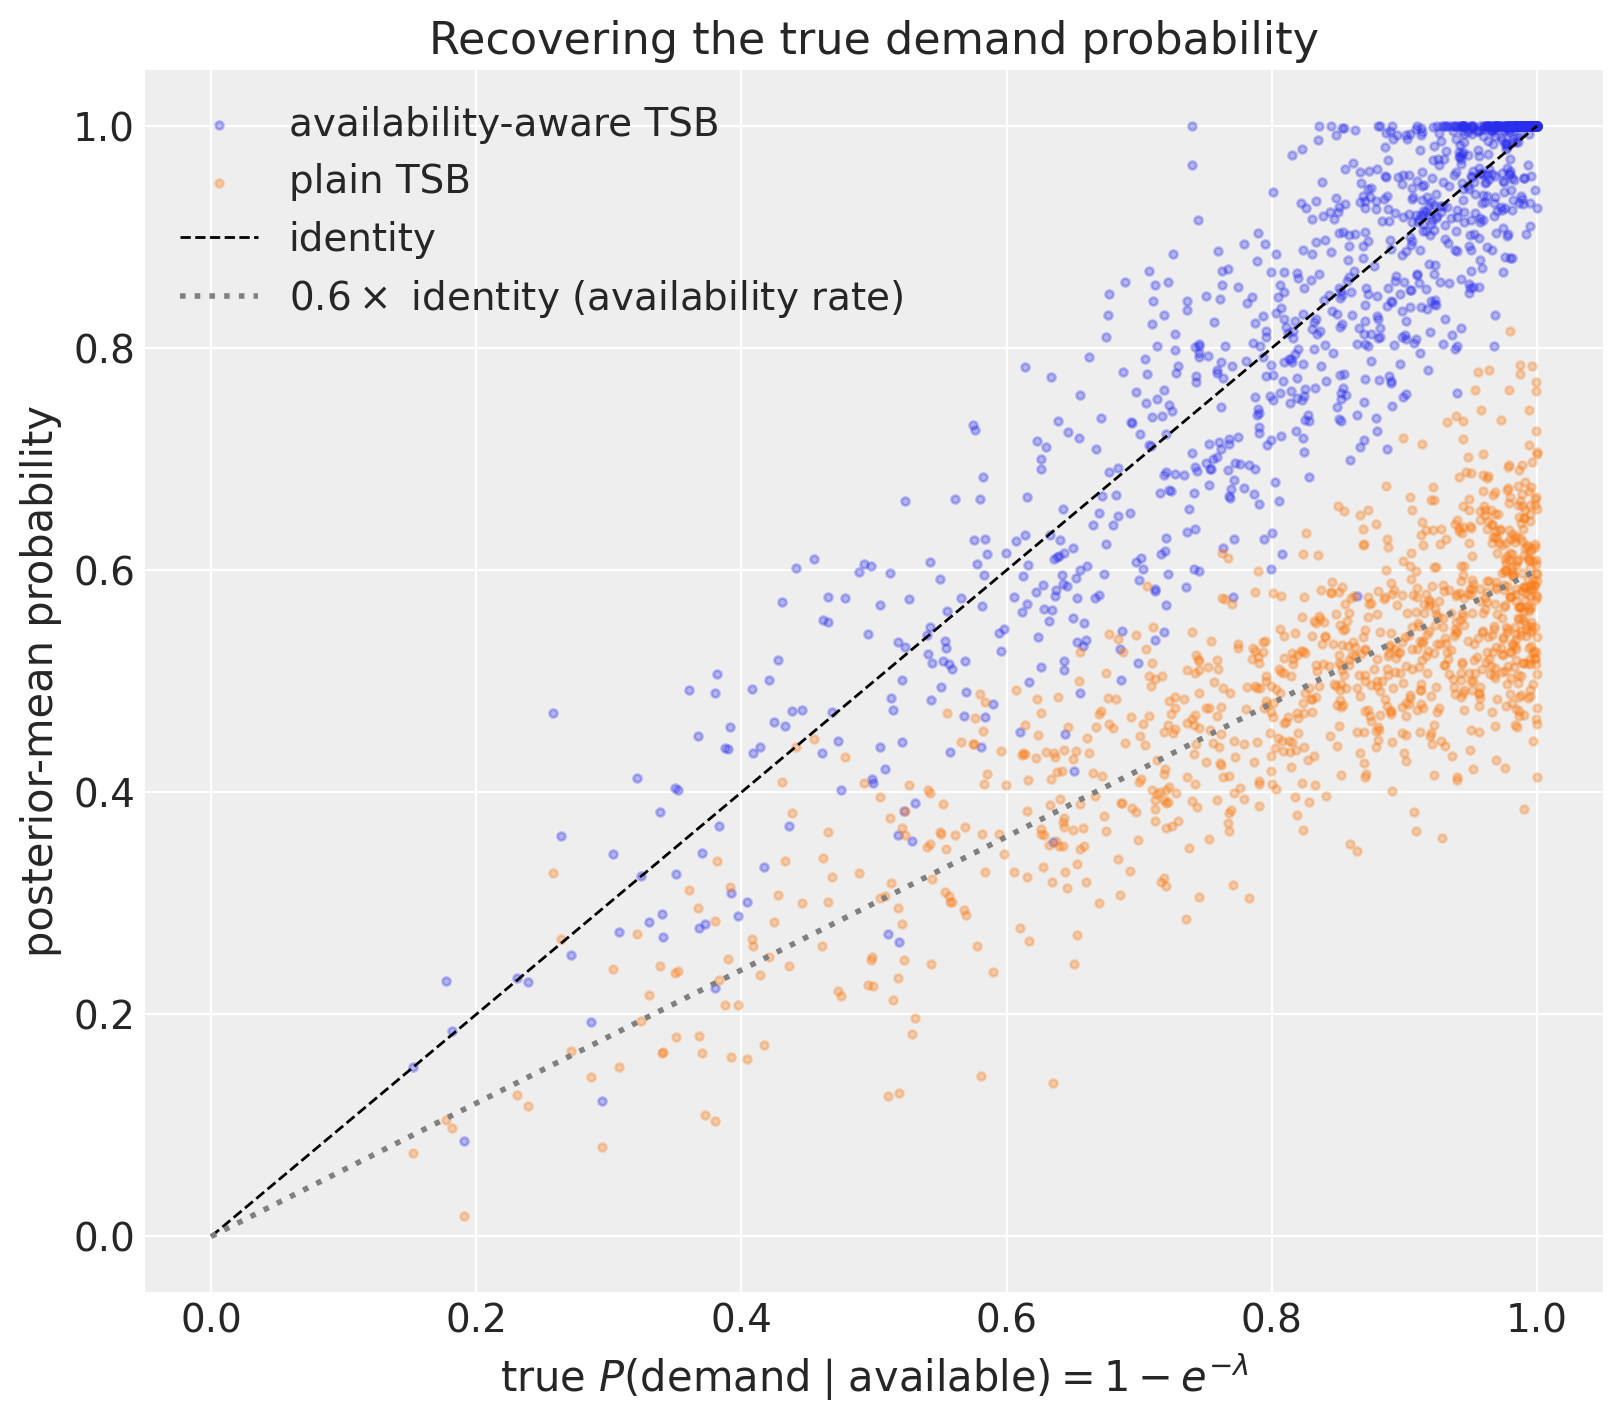

In [25]:
p_true = 1 - np.exp(-lam)
p_hat_aware = np.asarray(post["prob"])[:, t_max_train // 2 :, :].mean(axis=(0, 1))
p_hat_plain = np.asarray(post_plain["prob"])[:, t_max_train // 2 :, :].mean(axis=(0, 1))

ratio_aware = float(p_hat_aware.mean() / p_true.mean())
ratio_plain = float(p_hat_plain.mean() / p_true.mean())
print(f"mean estimated / true demand probability, availability-aware: {ratio_aware:.2f}")
print(f"mean estimated / true demand probability, plain TSB:          {ratio_plain:.2f}")

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(p_true, p_hat_aware, s=8, alpha=0.3, color="C0", label="availability-aware TSB")
ax.scatter(p_true, p_hat_plain, s=8, alpha=0.3, color="C1", label="plain TSB")
grid = np.linspace(0.0, 1.0, 100)
ax.plot(grid, grid, color="black", ls="--", lw=1, label="identity")
ax.plot(
    grid,
    availability_rate * grid,
    color="gray",
    ls=":",
    lw=2,
    label=r"$0.6 \times$ identity (availability rate)",
)
ax.legend(loc="upper left")
ax.set(
    title="Recovering the true demand probability",
    xlabel=r"true $P(\text{demand} \mid \text{available}) = 1 - e^{-\lambda}$",
    ylabel="posterior-mean probability",
);

The scatter is the whole argument in one picture: the availability-aware estimates line up with the identity, while the plain TSB estimates line up with the $0.6 \times$ line, exactly the $P(\text{available}) \cdot P(\text{demand} \mid \text{available})$ bias predicted in the comparison section. On observed *sales* under the historical availability regime that bias partly cancels (a censored probability times an uncensored future is roughly right on average), but the moment we ask the scenario question, plain TSB has no way to answer: its forecast of unconstrained demand inherits the bias in full.

One subtlety in setting the comparison up honestly: `forecast` reruns the model's recursions from the covariates it is given, so plain TSB's covariates must carry the all-ones availability input over the *whole* horizon, training window included. Feeding it the gated history would smuggle the availability information back into a method that, by definition, never sees it.

In [26]:
covariates_plain_full = jnp.stack([sales_input_full, jnp.ones_like(panel.available)], axis=0)

rng_key, rng_subkey = random.split(rng_key)
fc_full_plain = forecast(
    rng_subkey, model, post_plain, train_data, covariates_plain_full, batch_size=250, device="host"
)

total_aware = float(forecast_full.sum(axis=-1).mean())
total_plain = float(np.asarray(fc_full_plain).sum(axis=-1).mean())
print(f"true expected demand per period (sum of lambdas):     {expected_total:,.1f}")
print(
    f"full-availability forecast, availability-aware TSB:   {total_aware:,.1f} "
    f"({total_aware / expected_total:.0%} of truth)"
)
print(
    f"full-availability forecast, plain TSB:                {total_plain:,.1f} "
    f"({total_plain / expected_total:.0%} of truth)"
)

true expected demand per period (sum of lambdas):     2,471.8
full-availability forecast, availability-aware TSB:   2,481.3 (100% of truth)
full-availability forecast, plain TSB:                1,479.8 (60% of truth)


Finally, we return to the hero series from the forecast section, the fast mover whose training window ends in a stock-out run, and ask both fits the same scenario question: how much demand would there be with the product always on the shelf? For plain TSB the trailing run is a double blow. Its demand-probability estimate is biased low on *every* series (the $0.6 \times$ line above), and on this series it decayed further through each zero of the trailing run right before the forecast origin. The availability-aware fit froze through the same run.

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(


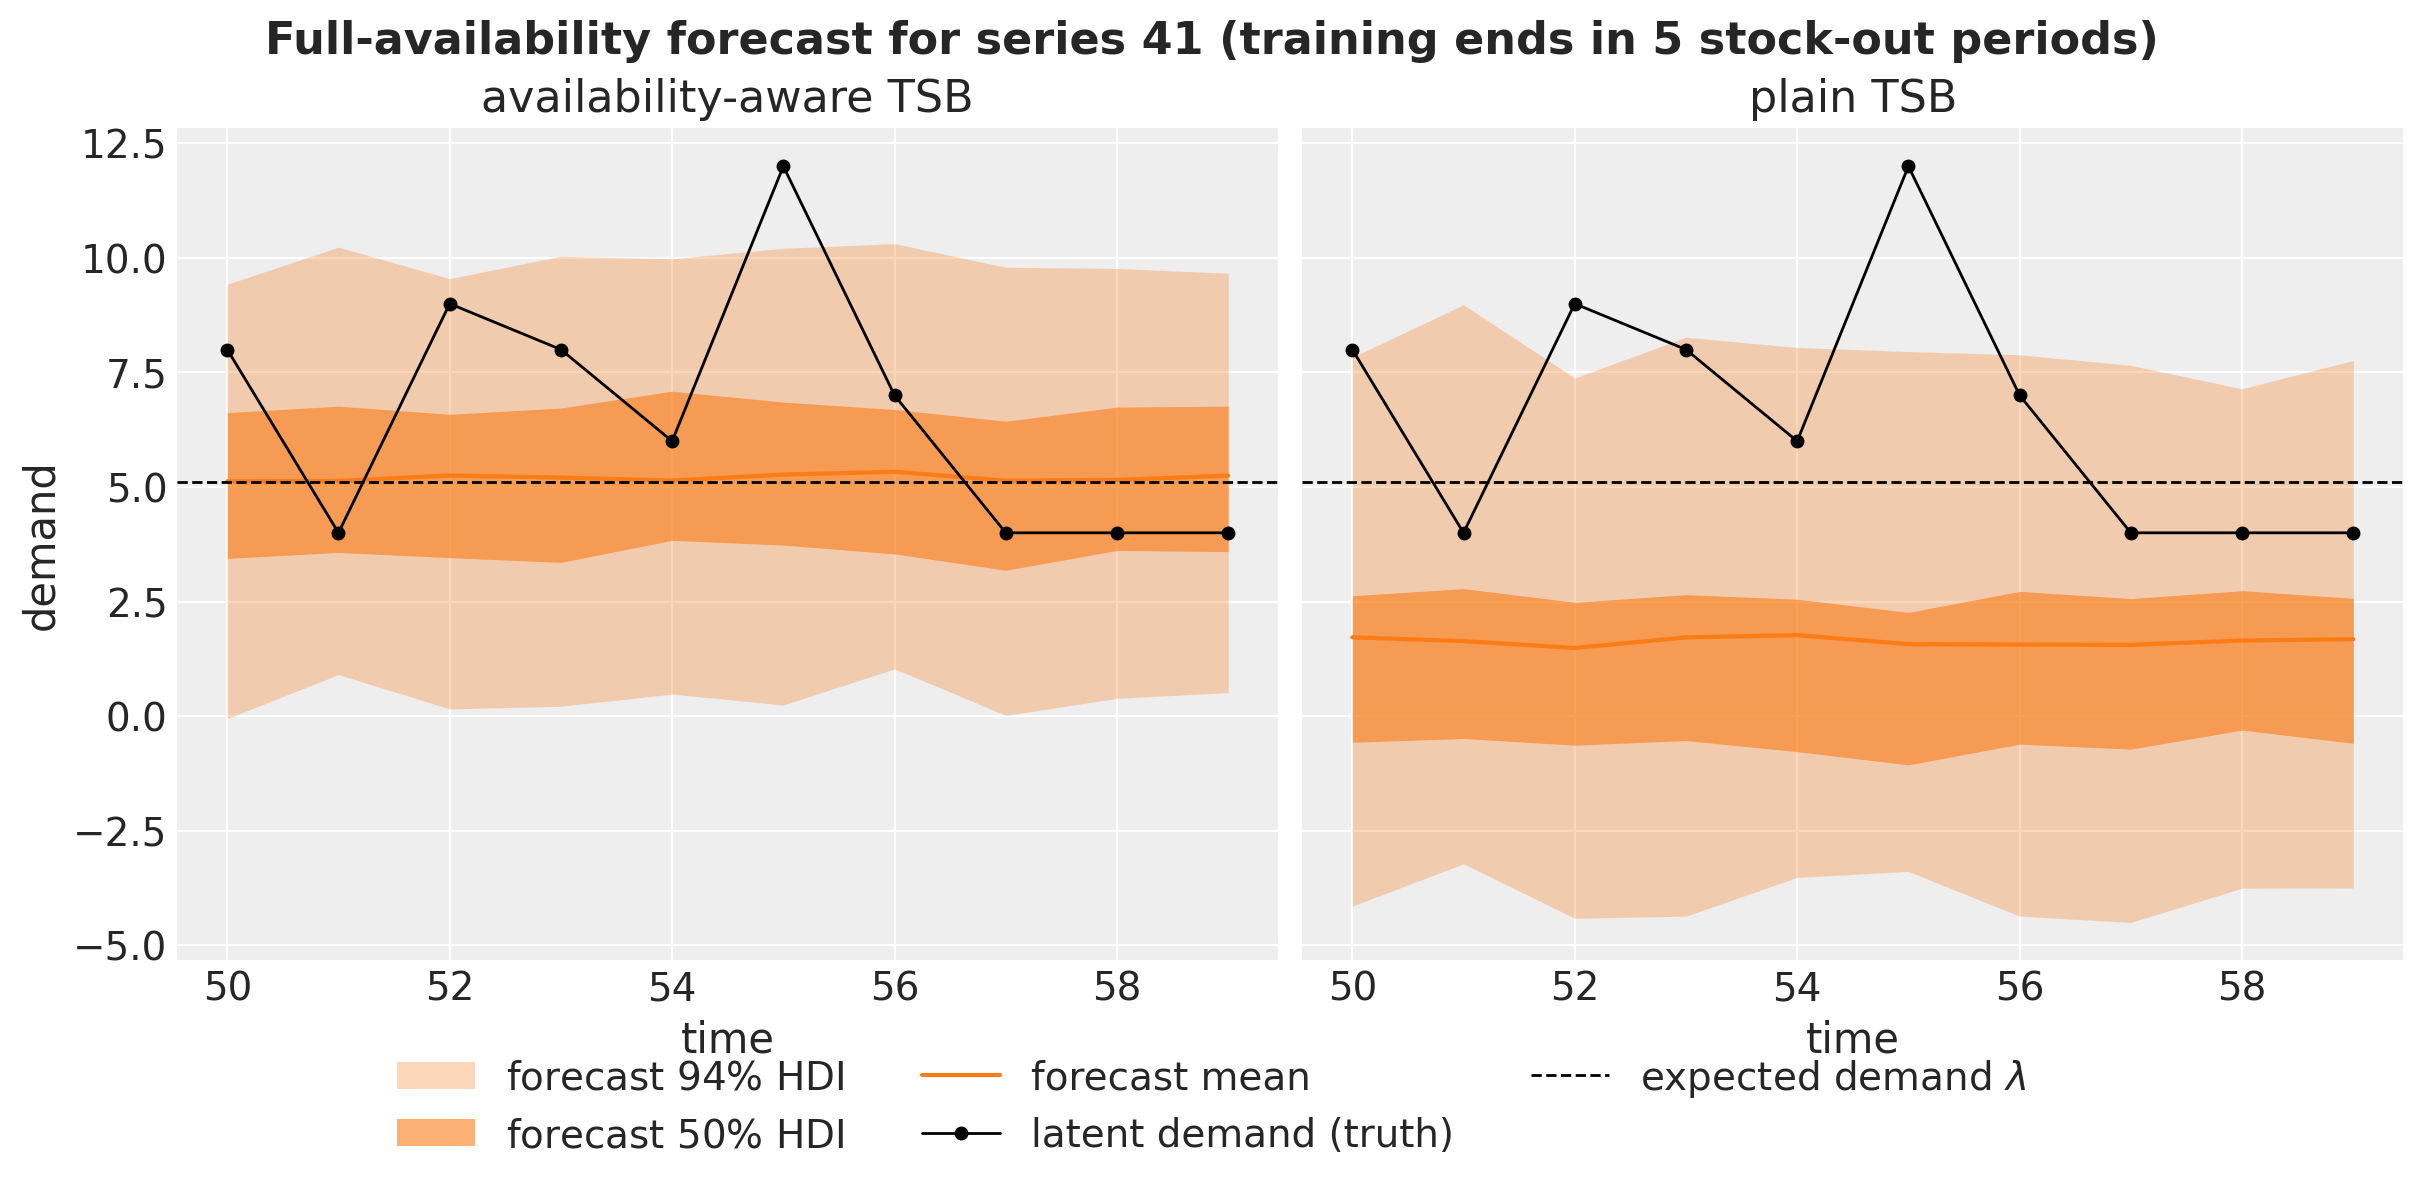

In [27]:
hero_draws = np.concatenate(
    [forecast_full[:, :, [k]], np.asarray(fc_full_plain)[:, :, [k]]], axis=-1
)
hero_labels = ["availability-aware TSB", "plain TSB"]
idata_hero = predictions_to_datatree(hero_draws, t_test.astype(float), hero_labels)
pc = az.plot_lm(
    idata_hero,
    y="obs",
    x="t",
    plot_dim="time",
    ci_kind="hdi",
    ci_prob=hdi_probs,
    smooth=False,
    point_estimate="mean",
    visuals={
        "ci_band": {"color": "C1"},
        "observed_scatter": False,
        "pe_line": {"color": "C1", "alpha": 1.0, "width": 1.5},
    },
    aes={"alpha": ["prob"]},
    alpha=hdi_alphas,
    figure_kwargs={"figsize": (12, 5), "sharex": True, "sharey": True},
)
axes = pc.viz["plot"]["t"]
for label in hero_labels:
    ax = axes.sel(series=label).item()
    (demand_line,) = ax.plot(
        t_test,
        np.asarray(panel.demand[t_max_train:, k]),
        "o-",
        color="black",
        lw=1,
        ms=4,
        label="latent demand (truth)",
    )
    lam_line = ax.axhline(lam[k], color="black", ls="--", lw=1, label=r"expected demand $\lambda$")
    ax.set(title=label, xlabel="time", ylabel="demand" if label == hero_labels[0] else "")
bands = pc.viz["ci_band"]["t"]
band_94 = bands.sel(series=hero_labels[0], prob=0.94).item()
band_50 = bands.sel(series=hero_labels[0], prob=0.5).item()
band_94.set_label(hdi_label(0.94, prefix="forecast "))
band_50.set_label(hdi_label(0.5, prefix="forecast "))
pe_line = pc.viz["pe_line"]["t"].sel(series=hero_labels[0]).item()
pe_line.set_label("forecast mean")
fig = pc.viz["figure"].item()
fig.legend(
    handles=[band_94, band_50, pe_line, demand_line, lam_line],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
)
fig.suptitle(
    f"Full-availability forecast for series {k} (training ends in {run_k} stock-out periods)",
    fontsize=16,
    fontweight="bold",
    y=1.05,
);

The two facets share the y axis, so the level gap *is* the story: the availability-aware forecast opens at the series' true demand level (dashed line) while the plain TSB forecast opens well below it, still paying for zeros that were never about demand. Multiply this picture by every series and every stock-out run in the panel and you get the aggregate shortfall printed above.

Asked how much the panel would sell with everything on the shelf, the availability-aware model lands close to the true expected demand while plain TSB misses low by roughly the availability rate: at scale, that is the difference between stocking for demand and stocking for last year's stock-outs.

As for Croston, the comparison stays conceptual: its occurrence bookkeeping lives on the event axis (inter-demand intervals), where a stock-out is indistinguishable from slow demand because it simply stretches the interval in progress. There is no per-period update to gate, which is why the availability hack needs TSB's calendar-axis demand-probability component as its starting point.

## A final note: what the availability mask buys you

It is worth collecting what the one-line change delivered, because each piece showed up in a different section:

- **Unbiased demand estimates.** The demand-probability component recovers $P(\text{demand} \mid \text{available})$ instead of the censored product, as the recovery scatter shows against ground truth.
- **Scenario forecasts.** Availability enters as an input (the trailing rows of the availability covariate), so the same posterior answers "what will we sell under the planned availability" and "what would demand be with everything on the shelf", the number replenishment actually needs. Plain TSB can only extrapolate the censored history.
- **No stock-out death spiral.** A forecast that decays with every stock-out under-forecasts, which under-stocks, which causes more stock-out zeros: a feedback loop the frozen update never enters.
- **Nearly free.** One extra input series and one gated update; plain TSB is recovered exactly at $a_t \equiv 1$, so nothing is lost where availability data does not exist.

The same caveats as in the sibling notebooks apply to the likelihood choices: Gaussian likelihoods for a count size and a $0/1$ indicator are the blog post's pragmatic simplification, and $\text{Bernoulli}$ occurrence or truncated size likelihoods are the natural refinements. The hack also treats availability as *exogenous*; when stock-outs correlate with demand (best-sellers sell out), the censoring is informative and the frozen update, while far better than the decaying one, is no longer the full story.

## References

- Orduz, J. [*Hacking the TSB Model for Intermittent Time Series to Accommodate for Availability Constraints*](https://juanitorduz.github.io/availability_tsb/). The blog post this notebook ports.
- The [TSB example](https://juanitorduz.github.io/numpyro_forecast/examples/tsb.html) in this documentation, whose two-component level-model construction this notebook promotes to a panel, and the blog post it ports: Orduz, J. [*TSB Method for Intermittent Time Series Forecasting in NumPyro*](https://juanitorduz.github.io/tsb_numpyro/).
- The [Croston example](https://juanitorduz.github.io/numpyro_forecast/examples/croston.html) in this documentation, the first notebook of the intermittent-demand trilogy.
- Teunter, R. H., Syntetos, A. A., & Babai, M. Z. (2011). *Intermittent demand: Linking forecasting to inventory obsolescence*. European Journal of Operational Research, 214(3), 606-615. The paper that introduces the TSB method.
- Croston, J. D. (1972). *Forecasting and stock control for intermittent demands*. Operational Research Quarterly, 23(3), 289-303.
- statsforecast documentation: [`TSB`](https://nixtlaverse.nixtla.io/statsforecast/docs/models/tsb.html), the classical TSB baseline.